# Experimento 02: Análisis de Topología Muscular (FDS vs. ED)

El objetivo de este experimento es evaluar y comparar el desempeño general entre el **Flexor Superficial de los Dedos (FDS)** y el **Extensor de los Dedos (ED)**.
Utilizaremos los hiperparámetros óptimos extraídos en el Experimento 01 (`config.py`) para entrenar los tres modelos sobre todos los sujetos de forma intra-usuario.
Al promediar/sumar las matrices de confusión de todos los usuarios, demostraremos estadísticamente las asimetrías de clase inherentes a la biología y justificaremos las limitaciones de usar un único canal.

In [1]:
import sys
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Añadir el directorio padre al path para importar 'src'
sys.path.append(os.path.abspath('../..'))

from src import config, dataset, features
from src.models import rf, svm, cnn

# Definir clases
GESTURES = {0: "Reposo", 1: "Palma", 2: "Puño", 3: "Paz"}
NUM_CLASSES = 4
classes = [GESTURES[i] for i in range(NUM_CLASSES)]

I0000 00:00:1782425159.446735    3389 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782425159.859007    3389 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782425161.122509    3389 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
muscles = ['FDS', 'ED']
base_raw_path = os.environ.get("RAW_DATA_PATH", "../../datasets/raw/myotensor_proto/")

# Buscar sujetos disponibles
subject_paths = glob.glob(f"{base_raw_path}/FDS/S*")
subjects = [os.path.basename(p) for p in subject_paths]
subjects.sort()

# Diccionario para guardar resultados individuales
results = {sub: {m: {'SVM': {}, 'RF': {}, 'CNN': {}} for m in muscles} for sub in subjects}

for muscle in muscles:
    print(f"\n{'='*60}")
    print(f"=== EVALUANDO MÚSCULO: {muscle} ===")
    print(f"{'='*60}")
    
    if not subjects:
        print(f"  [!] No se encontraron sujetos para {muscle}")
        continue
        
    for subject in subjects:
        print(f"\n[*] Sujeto: {subject}")
        
        # --- 1. SVM ---
        w_svm, s_svm = config.get_best_window_stride(muscle, 'SVM')
        try:
            X_tr_raw, y_tr, X_te_raw, y_te = dataset.load_and_segment_dataset(subject, muscle, w_svm, s_svm)
            X_tr_feat = features.extract_features(X_tr_raw, subject, muscle)
            X_te_feat = features.extract_features(X_te_raw, subject, muscle)
            X_tr_sc, X_te_sc, _ = features.scale_features(X_tr_feat, X_te_feat)
            
            model_svm = svm.train_with_gridsearch(X_tr_sc, y_tr)
            acc, _ = svm.evaluate(model_svm, X_te_sc, y_te)
            y_pred = model_svm.predict(X_te_sc)
            results[subject][muscle]['SVM'] = {'y_true': y_te.tolist(), 'y_pred': y_pred.tolist(), 'acc': acc}
            print(f"  -> SVM (W={w_svm}, S={s_svm}) Accuracy: {acc*100:.2f}%")
        except Exception as e:
            print(f"  [!] Error en SVM: {e}")
            
        # --- 2. RF ---
        w_rf, s_rf = config.get_best_window_stride(muscle, 'RF')
        try:
            X_tr_raw, y_tr, X_te_raw, y_te = dataset.load_and_segment_dataset(subject, muscle, w_rf, s_rf)
            X_tr_feat = features.extract_features(X_tr_raw, subject, muscle)
            X_te_feat = features.extract_features(X_te_raw, subject, muscle)
            
            model_rf = rf.train_with_gridsearch(X_tr_feat, y_tr)
            acc, _ = rf.evaluate(model_rf, X_te_feat, y_te)
            y_pred = model_rf.predict(X_te_feat)
            results[subject][muscle]['RF'] = {'y_true': y_te.tolist(), 'y_pred': y_pred.tolist(), 'acc': acc}
            print(f"  -> RF  (W={w_rf}, S={s_rf}) Accuracy: {acc*100:.2f}%")
        except Exception as e:
            print(f"  [!] Error en RF: {e}")
            
        # --- 3. CNN-LSTM ---
        w_cnn, s_cnn = config.get_best_window_stride(muscle, 'CNN')
        try:
            X_tr_raw, y_tr, X_te_raw, y_te = dataset.load_and_segment_dataset(subject, muscle, w_cnn, s_cnn)
            model_cnn_base = cnn.build_model(window_size=w_cnn)
            
            # Entrenamos normalmente sin pruning por velocidad
            X_tr_cnn = np.expand_dims(X_tr_raw, axis=-1) if X_tr_raw.ndim == 2 else X_tr_raw
            X_te_cnn = np.expand_dims(X_te_raw, axis=-1) if X_te_raw.ndim == 2 else X_te_raw
            
            model_cnn_base.fit(X_tr_cnn, y_tr, epochs=15, batch_size=32, verbose=0)
            
            y_pred_prob = model_cnn_base.predict(X_te_cnn, verbose=0)
            y_pred = np.argmax(y_pred_prob, axis=1)
            acc = accuracy_score(y_te, y_pred)
            results[subject][muscle]['CNN'] = {'y_true': y_te.tolist(), 'y_pred': y_pred.tolist(), 'acc': float(acc)}
            print(f"  -> CNN (W={w_cnn}, S={s_cnn}) Accuracy: {acc*100:.2f}%")
        except Exception as e:
            print(f"  [!] Error en CNN: {e}")



=== EVALUANDO MÚSCULO: FDS ===

[*] Sujeto: S01
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=200, S=100) Accuracy: 80.92%
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  -> RF  (W=300, S=100) Accuracy: 79.65%


W0000 00:00:1782425175.462130    3389 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


  -> CNN (W=400, S=25) Accuracy: 81.52%

[*] Sujeto: S02
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=200, S=100) Accuracy: 63.57%
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  -> RF  (W=300, S=100) Accuracy: 69.68%
  -> CNN (W=400, S=25) Accuracy: 67.15%

[*] Sujeto: S03
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=200, S=100) Accuracy: 85.13%
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  -> RF  (W=300, S=100) Accuracy: 82.51%
  -> CNN (W=400, S=25) Accuracy: 78.90%

[*] Sujeto: S04
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=200, S=100) Accuracy: 89.77%
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  -> RF  (W=300, S=100) Accuracy: 91.84%
  -> CNN (W=400, S=25) Accuracy: 66.67%

[*] Sujeto: S05
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=200, S=100) Accuracy: 57.66%
Fitting 5 folds for each of 27 candidates, totallin

/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

  -> SVM (W=200, S=100) Accuracy: 82.66%
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

  -> RF  (W=300, S=100) Accuracy: 83.57%
  -> CNN (W=400, S=25) Accuracy: 90.95%

[*] Sujeto: S08
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=200, S=100) Accuracy: 64.92%
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  -> RF  (W=300, S=100) Accuracy: 65.85%
  -> CNN (W=400, S=25) Accuracy: 71.19%

[*] Sujeto: S10
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=200, S=100) Accuracy: 88.03%
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  -> RF  (W=300, S=100) Accuracy: 86.62%
  -> CNN (W=400, S=25) Accuracy: 92.44%

=== EVALUANDO MÚSCULO: ED ===

[*] Sujeto: S01
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=400, S=100) Accuracy: 97.38%
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  -> RF  (W=400, S=100) Accuracy: 96.72%
  -> CNN (W=300, S=25) Accuracy: 97.47%

[*] Sujeto: S02
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  -> SVM (W=400, S=1

## Resultados Individuales por Sujeto

Visualización de las matrices de confusión y reportes de clasificación para cada sujeto y cada músculo.


=== RESULTADOS INDIVIDUALES: S01 ===


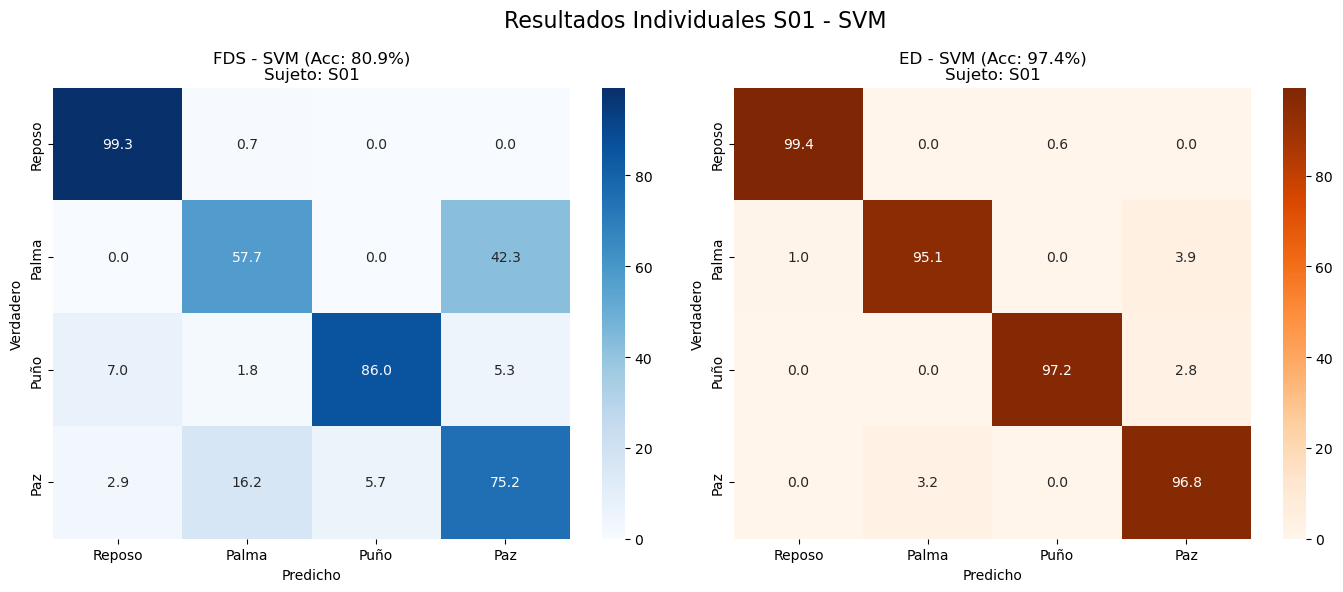


--- Reporte de Clasificación S01 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.99      0.97       148
       Palma       0.76      0.58      0.66       104
        Puño       0.89      0.86      0.88        57
         Paz       0.63      0.75      0.68       105

    accuracy                           0.81       414
   macro avg       0.81      0.80      0.80       414
weighted avg       0.81      0.81      0.81       414

--- Reporte de Clasificación S01 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.99      0.99       157
       Palma       0.97      0.95      0.96       102
        Puño       0.99      0.97      0.98       106
         Paz       0.93      0.97      0.95        93

    accuracy                           0.97       458
   macro avg       0.97      0.97      0.97       458
weighted avg       0.97      0.97      0.97       458



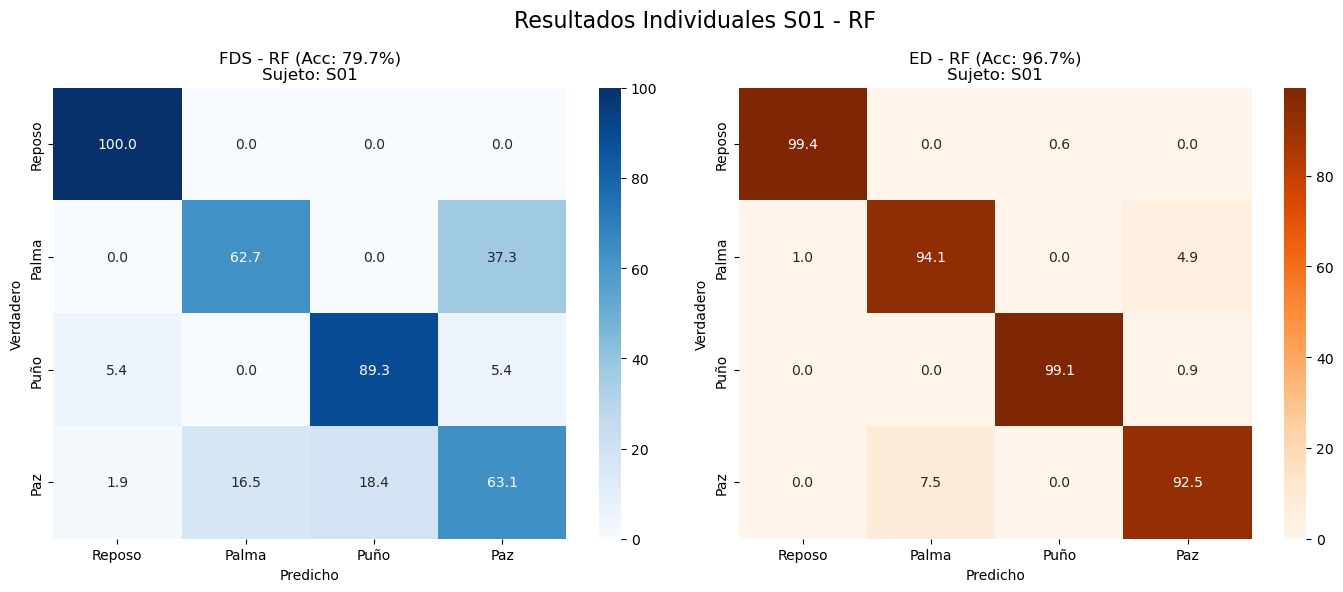


--- Reporte de Clasificación S01 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.97      1.00      0.98       142
       Palma       0.79      0.63      0.70       102
        Puño       0.72      0.89      0.80        56
         Paz       0.61      0.63      0.62       103

    accuracy                           0.80       403
   macro avg       0.77      0.79      0.78       403
weighted avg       0.80      0.80      0.79       403

--- Reporte de Clasificación S01 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.99      0.99       157
       Palma       0.93      0.94      0.94       102
        Puño       0.99      0.99      0.99       106
         Paz       0.93      0.92      0.93        93

    accuracy                           0.97       458
   macro avg       0.96      0.96      0.96       458
weighted avg       0.97      0.97      0.97       458



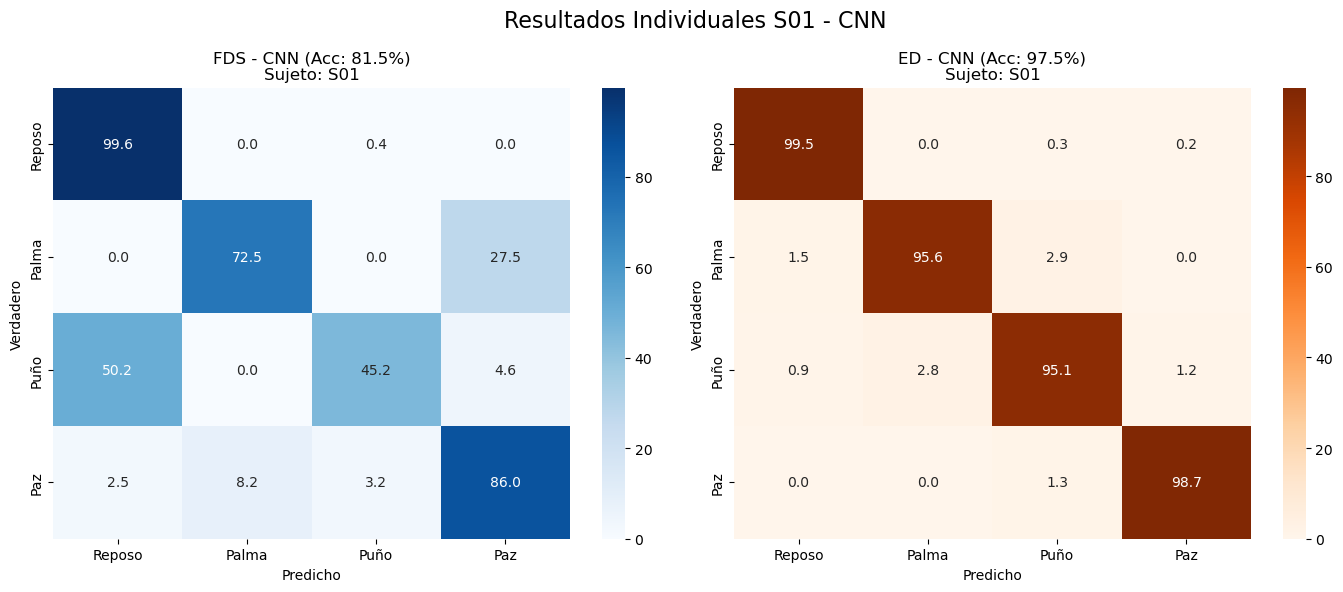


--- Reporte de Clasificación S01 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.82      1.00      0.90       534
       Palma       0.90      0.72      0.80       396
        Puño       0.87      0.45      0.59       217
         Paz       0.74      0.86      0.80       401

    accuracy                           0.82      1548
   macro avg       0.83      0.76      0.77      1548
weighted avg       0.83      0.82      0.80      1548

--- Reporte de Clasificación S01 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.98      1.00      0.99       637
       Palma       0.97      0.96      0.96       413
        Puño       0.96      0.95      0.95       429
         Paz       0.98      0.99      0.99       378

    accuracy                           0.97      1857
   macro avg       0.97      0.97      0.97      1857
weighted avg       0.97      0.97      0.97      1857


=== RESULTADOS INDIVIDUALES: S02 ==

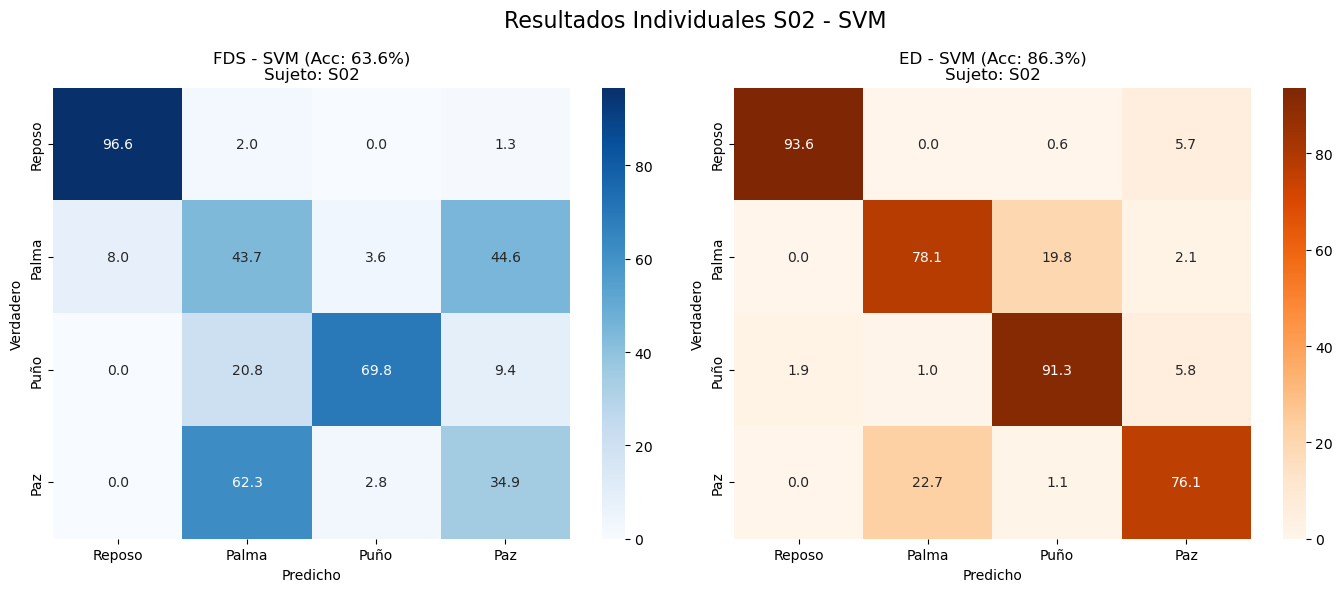


--- Reporte de Clasificación S02 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.94      0.97      0.95       149
       Palma       0.38      0.44      0.41       112
        Puño       0.84      0.70      0.76        53
         Paz       0.39      0.35      0.37       106

    accuracy                           0.64       420
   macro avg       0.64      0.61      0.62       420
weighted avg       0.64      0.64      0.64       420

--- Reporte de Clasificación S02 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.94      0.96       157
       Palma       0.78      0.78      0.78        96
        Puño       0.82      0.91      0.86       103
         Paz       0.80      0.76      0.78        88

    accuracy                           0.86       444
   macro avg       0.85      0.85      0.85       444
weighted avg       0.87      0.86      0.86       444



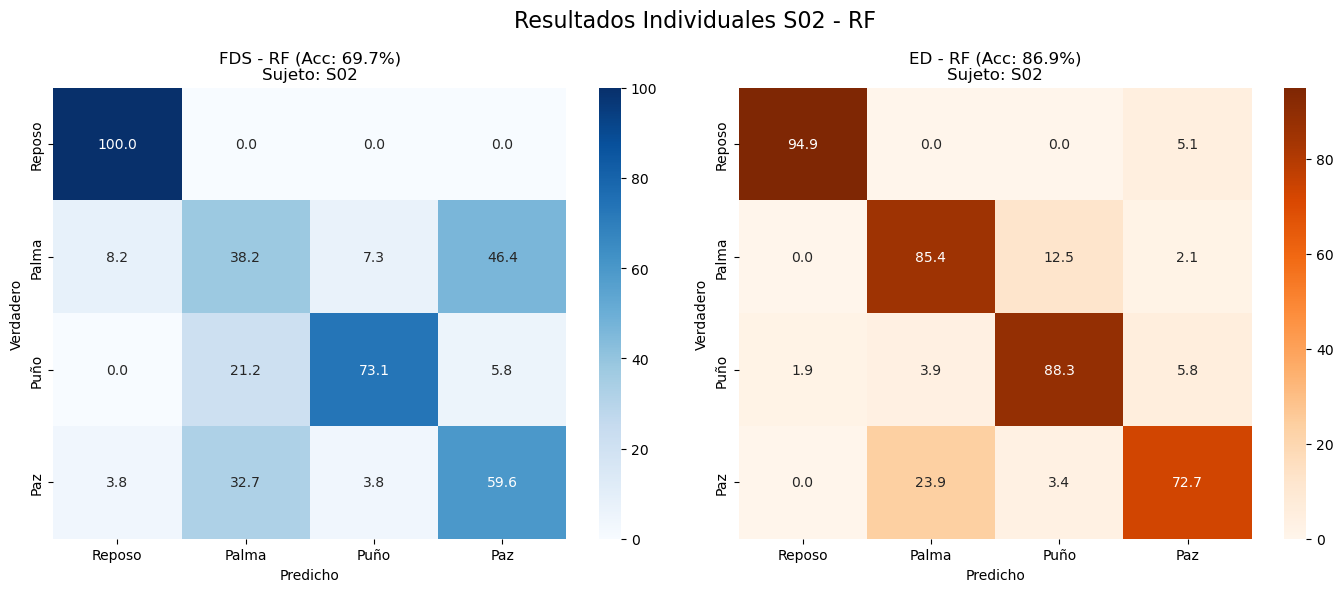


--- Reporte de Clasificación S02 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.92      1.00      0.96       143
       Palma       0.48      0.38      0.43       110
        Puño       0.76      0.73      0.75        52
         Paz       0.53      0.60      0.56       104

    accuracy                           0.70       409
   macro avg       0.67      0.68      0.67       409
weighted avg       0.68      0.70      0.69       409

--- Reporte de Clasificación S02 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.95      0.97       157
       Palma       0.77      0.85      0.81        96
        Puño       0.86      0.88      0.87       103
         Paz       0.80      0.73      0.76        88

    accuracy                           0.87       444
   macro avg       0.85      0.85      0.85       444
weighted avg       0.87      0.87      0.87       444



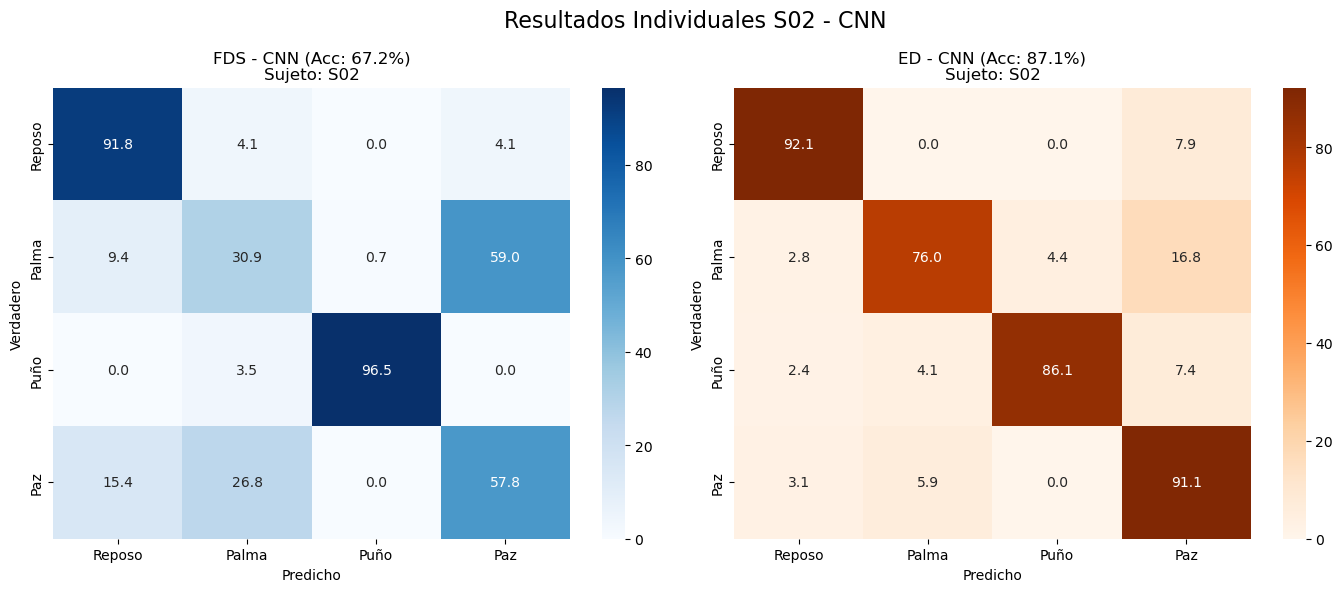


--- Reporte de Clasificación S02 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.83      0.92      0.87       539
       Palma       0.49      0.31      0.38       427
        Puño       0.98      0.97      0.97       202
         Paz       0.46      0.58      0.51       403

    accuracy                           0.67      1571
   macro avg       0.69      0.69      0.68      1571
weighted avg       0.66      0.67      0.66      1571

--- Reporte de Clasificación S02 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.92      0.93       646
       Palma       0.89      0.76      0.82       387
        Puño       0.95      0.86      0.91       417
         Paz       0.69      0.91      0.78       358

    accuracy                           0.87      1808
   macro avg       0.87      0.86      0.86      1808
weighted avg       0.89      0.87      0.87      1808


=== RESULTADOS INDIVIDUALES: S03 ==

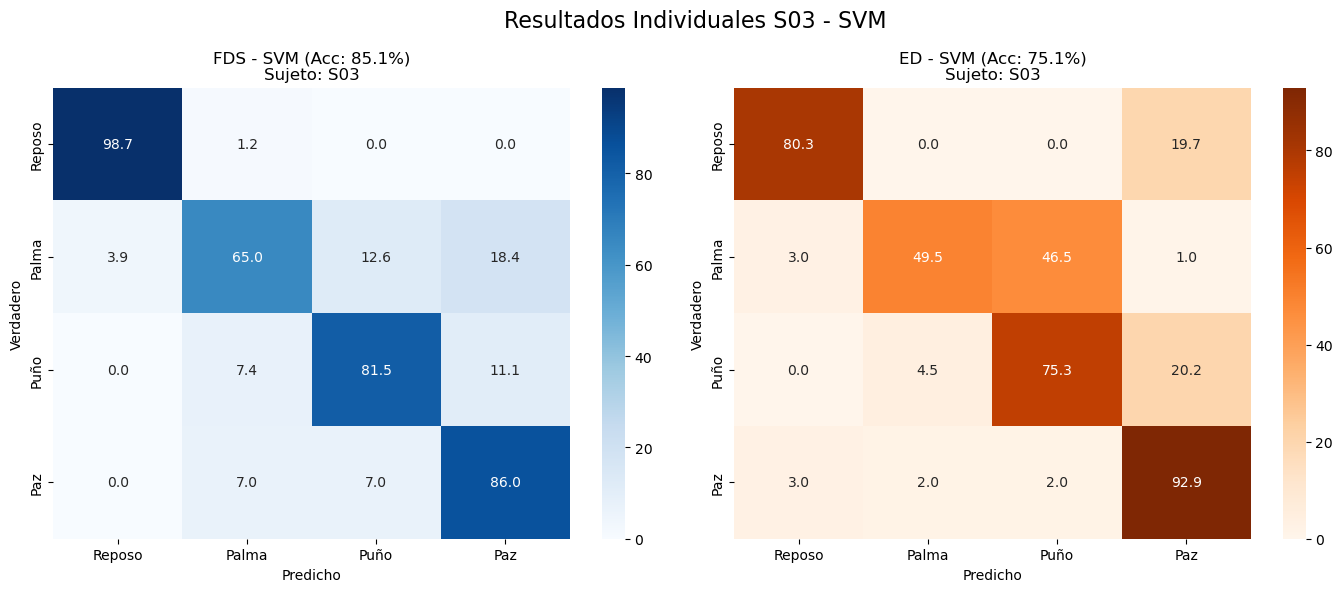


--- Reporte de Clasificación S03 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.99      0.98       160
       Palma       0.84      0.65      0.73       103
        Puño       0.69      0.81      0.75        54
         Paz       0.77      0.86      0.82       100

    accuracy                           0.85       417
   macro avg       0.82      0.83      0.82       417
weighted avg       0.86      0.85      0.85       417

--- Reporte de Clasificación S03 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.80      0.87       157
       Palma       0.89      0.50      0.64       101
        Puño       0.58      0.75      0.65        89
         Paz       0.65      0.93      0.76        99

    accuracy                           0.75       446
   macro avg       0.77      0.74      0.73       446
weighted avg       0.80      0.75      0.75       446



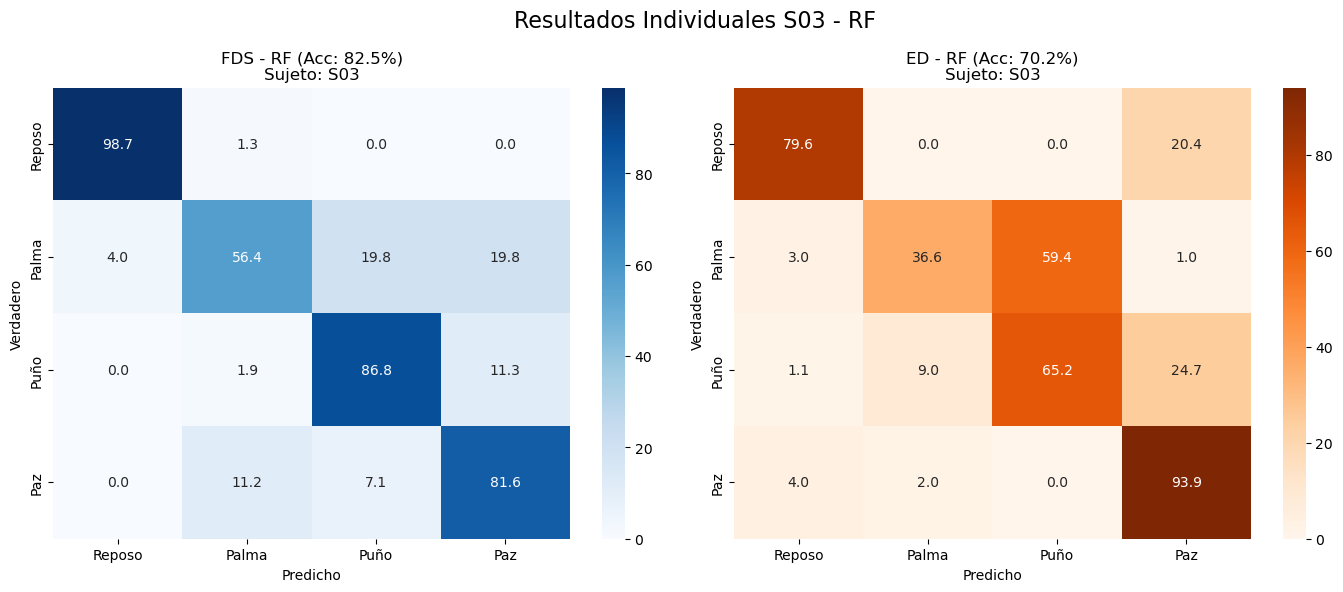


--- Reporte de Clasificación S03 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.99      0.98       154
       Palma       0.80      0.56      0.66       101
        Puño       0.63      0.87      0.73        53
         Paz       0.75      0.82      0.78        98

    accuracy                           0.83       406
   macro avg       0.79      0.81      0.79       406
weighted avg       0.83      0.83      0.82       406

--- Reporte de Clasificación S03 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.94      0.80      0.86       157
       Palma       0.79      0.37      0.50       101
        Puño       0.49      0.65      0.56        89
         Paz       0.63      0.94      0.75        99

    accuracy                           0.70       446
   macro avg       0.71      0.69      0.67       446
weighted avg       0.75      0.70      0.70       446



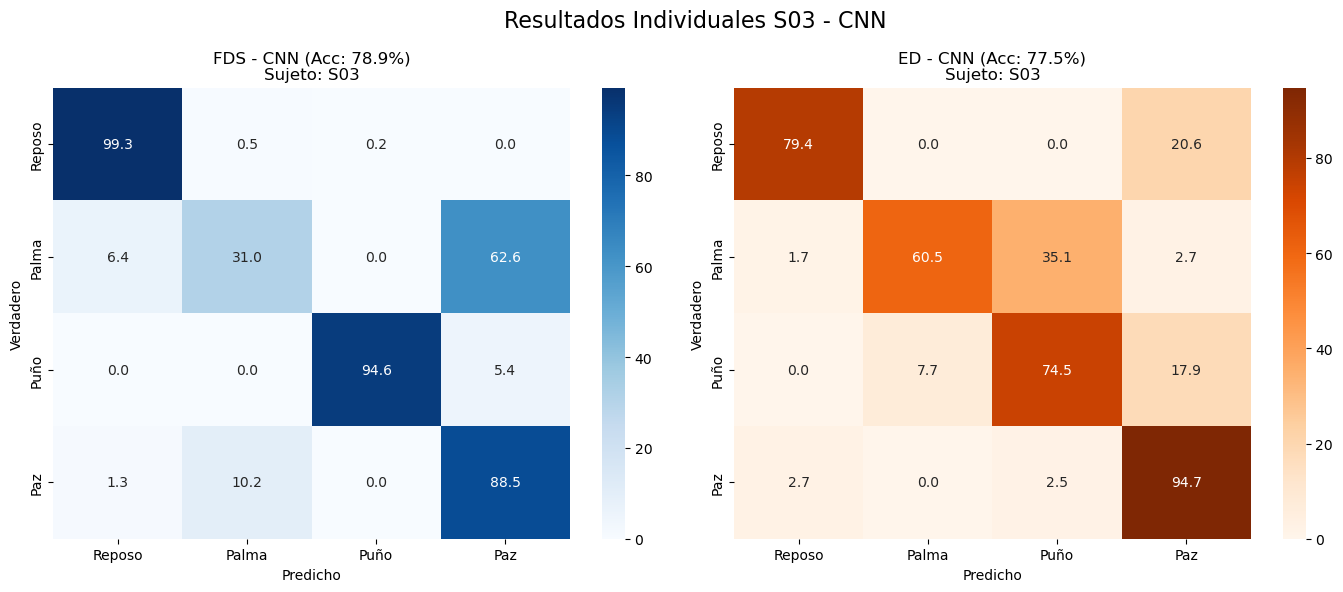


--- Reporte de Clasificación S03 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.99      0.97       584
       Palma       0.74      0.31      0.44       393
        Puño       0.99      0.95      0.97       205
         Paz       0.57      0.88      0.69       382

    accuracy                           0.79      1564
   macro avg       0.81      0.78      0.77      1564
weighted avg       0.81      0.79      0.77      1564

--- Reporte de Clasificación S03 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.79      0.87       641
       Palma       0.90      0.60      0.72       410
        Puño       0.64      0.74      0.69       364
         Paz       0.65      0.95      0.77       400

    accuracy                           0.78      1815
   macro avg       0.79      0.77      0.76      1815
weighted avg       0.81      0.78      0.78      1815


=== RESULTADOS INDIVIDUALES: S04 ==

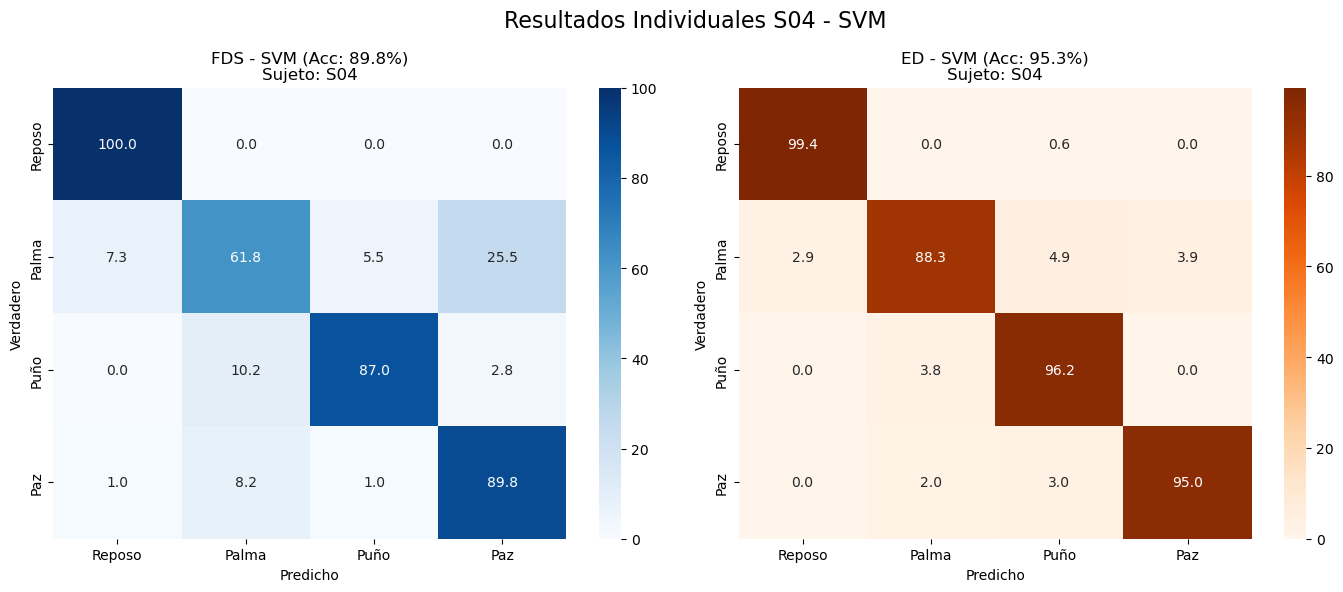


--- Reporte de Clasificación S04 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.97      1.00      0.99       179
       Palma       0.64      0.62      0.63        55
        Puño       0.96      0.87      0.91       108
         Paz       0.84      0.90      0.87        98

    accuracy                           0.90       440
   macro avg       0.85      0.85      0.85       440
weighted avg       0.90      0.90      0.90       440

--- Reporte de Clasificación S04 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.99      0.99       156
       Palma       0.94      0.88      0.91       103
        Puño       0.92      0.96      0.94       105
         Paz       0.96      0.95      0.96       101

    accuracy                           0.95       465
   macro avg       0.95      0.95      0.95       465
weighted avg       0.95      0.95      0.95       465



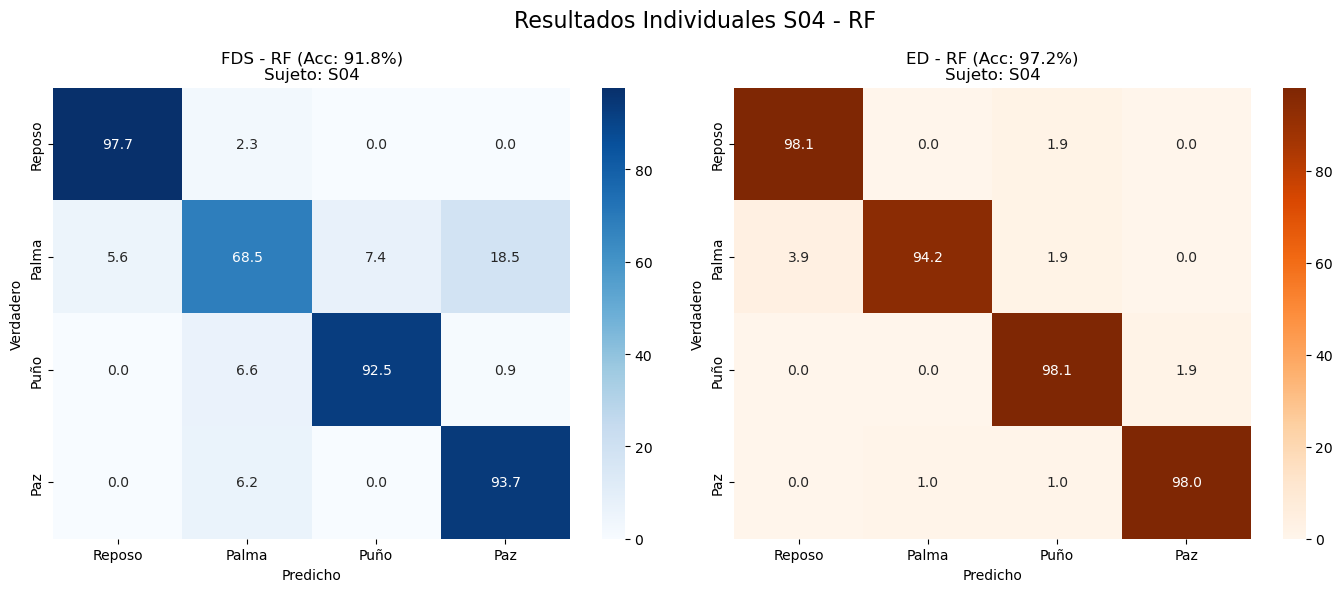


--- Reporte de Clasificación S04 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.98      0.98       173
       Palma       0.69      0.69      0.69        54
        Puño       0.96      0.92      0.94       106
         Paz       0.89      0.94      0.91        96

    accuracy                           0.92       429
   macro avg       0.88      0.88      0.88       429
weighted avg       0.92      0.92      0.92       429

--- Reporte de Clasificación S04 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.98      0.98       156
       Palma       0.99      0.94      0.97       103
        Puño       0.94      0.98      0.96       105
         Paz       0.98      0.98      0.98       101

    accuracy                           0.97       465
   macro avg       0.97      0.97      0.97       465
weighted avg       0.97      0.97      0.97       465



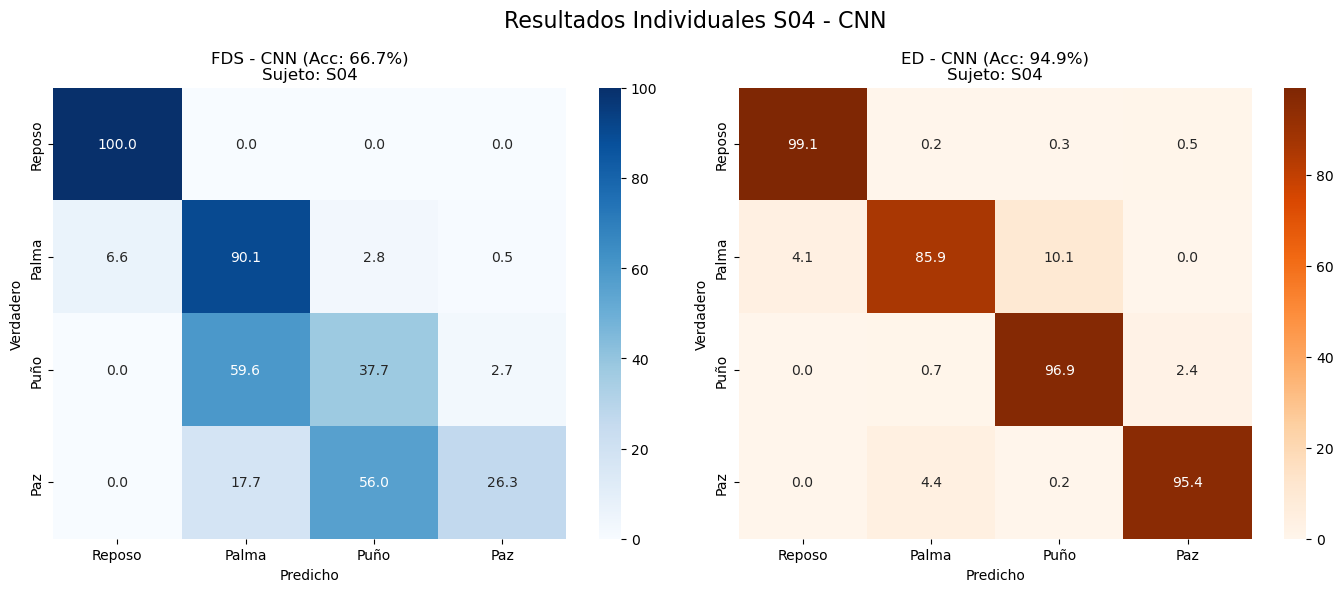


--- Reporte de Clasificación S04 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.98      1.00      0.99       660
       Palma       0.38      0.90      0.54       212
        Puño       0.42      0.38      0.40       411
         Paz       0.89      0.26      0.41       373

    accuracy                           0.67      1656
   macro avg       0.67      0.64      0.58      1656
weighted avg       0.74      0.67      0.65      1656

--- Reporte de Clasificación S04 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.99      0.98       638
       Palma       0.94      0.86      0.90       417
        Puño       0.90      0.97      0.93       423
         Paz       0.97      0.95      0.96       410

    accuracy                           0.95      1888
   macro avg       0.95      0.94      0.94      1888
weighted avg       0.95      0.95      0.95      1888


=== RESULTADOS INDIVIDUALES: S05 ==

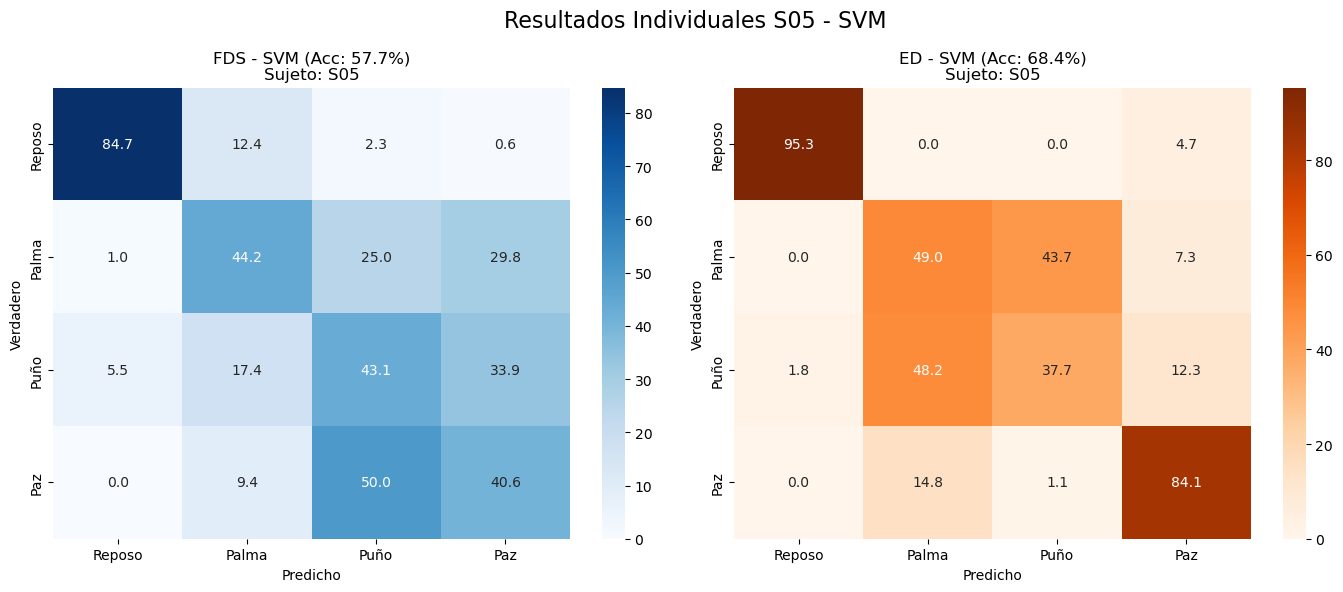


--- Reporte de Clasificación S05 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.96      0.85      0.90       177
       Palma       0.47      0.44      0.46       104
        Puño       0.36      0.43      0.39       109
         Paz       0.38      0.41      0.39       106

    accuracy                           0.58       496
   macro avg       0.54      0.53      0.54       496
weighted avg       0.60      0.58      0.59       496

--- Reporte de Clasificación S05 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.95      0.97       148
       Palma       0.41      0.49      0.45        96
        Puño       0.50      0.38      0.43       114
         Paz       0.73      0.84      0.78        88

    accuracy                           0.68       446
   macro avg       0.66      0.67      0.66       446
weighted avg       0.69      0.68      0.68       446



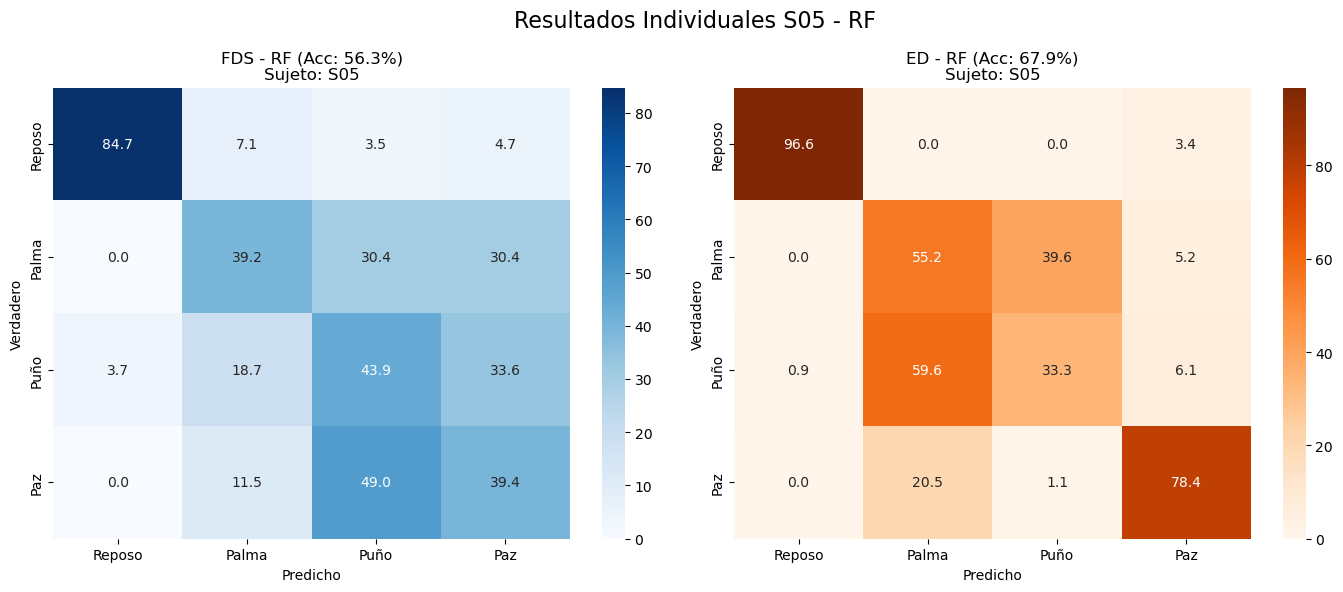


--- Reporte de Clasificación S05 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.85      0.91       170
       Palma       0.48      0.39      0.43       102
        Puño       0.35      0.44      0.39       107
         Paz       0.35      0.39      0.37       104

    accuracy                           0.56       483
   macro avg       0.54      0.52      0.52       483
weighted avg       0.60      0.56      0.58       483

--- Reporte de Clasificación S05 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.97      0.98       148
       Palma       0.38      0.55      0.45        96
        Puño       0.49      0.33      0.40       114
         Paz       0.80      0.78      0.79        88

    accuracy                           0.68       446
   macro avg       0.67      0.66      0.66       446
weighted avg       0.70      0.68      0.68       446



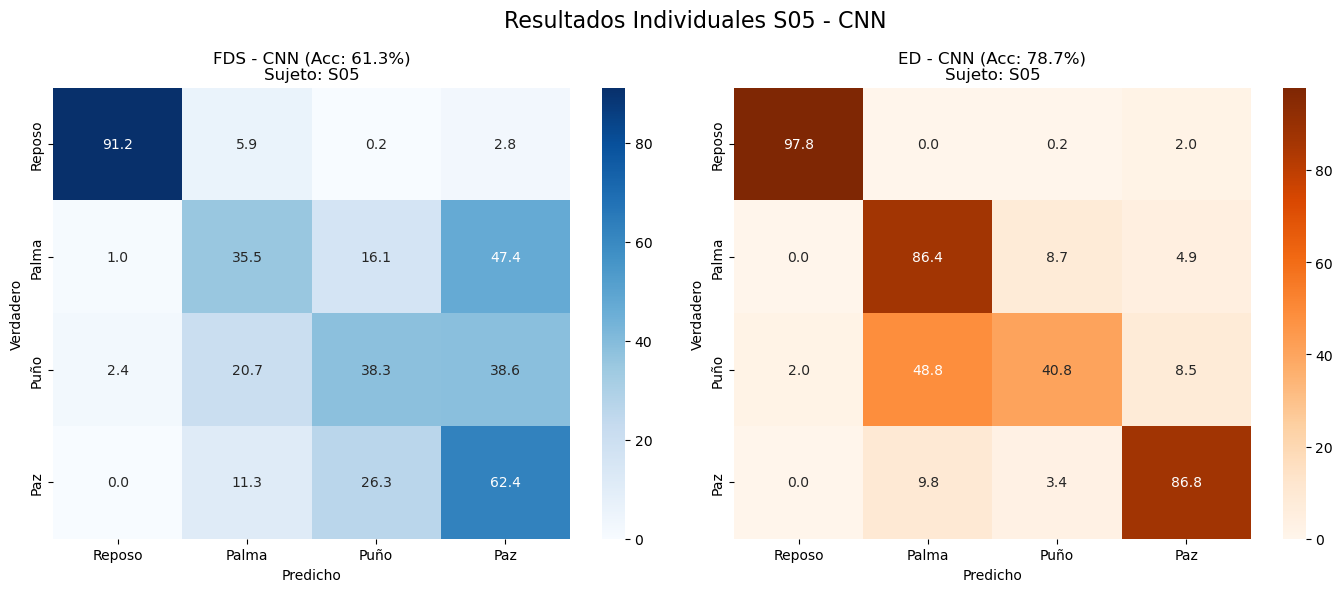


--- Reporte de Clasificación S05 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.91      0.94       645
       Palma       0.45      0.36      0.40       397
        Puño       0.48      0.38      0.43       415
         Paz       0.41      0.62      0.49       407

    accuracy                           0.61      1864
   macro avg       0.58      0.57      0.57      1864
weighted avg       0.63      0.61      0.61      1864

--- Reporte de Clasificación S05 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.98      0.98       603
       Palma       0.56      0.86      0.68       390
        Puño       0.80      0.41      0.54       461
         Paz       0.82      0.87      0.84       357

    accuracy                           0.79      1811
   macro avg       0.79      0.78      0.76      1811
weighted avg       0.81      0.79      0.78      1811


=== RESULTADOS INDIVIDUALES: S06 ==

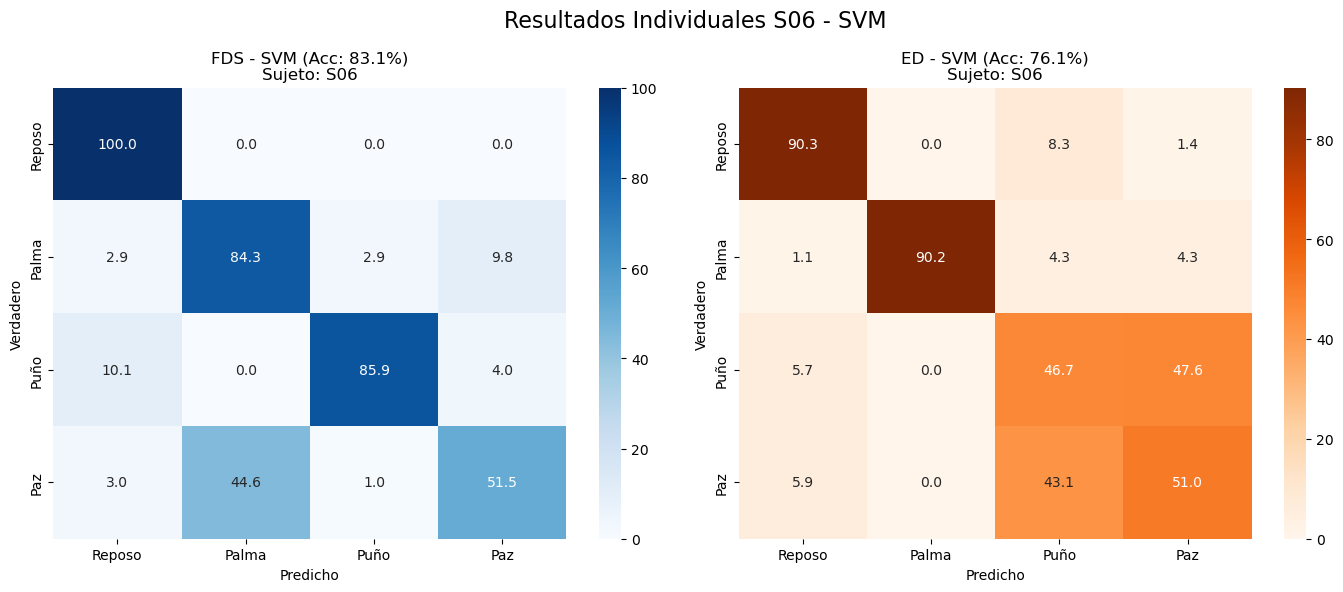


--- Reporte de Clasificación S06 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.91      1.00      0.95       166
       Palma       0.66      0.84      0.74       102
        Puño       0.96      0.86      0.90        99
         Paz       0.79      0.51      0.62       101

    accuracy                           0.83       468
   macro avg       0.83      0.80      0.80       468
weighted avg       0.84      0.83      0.82       468

--- Reporte de Clasificación S06 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.90      0.93       217
       Palma       1.00      0.90      0.95        92
        Puño       0.53      0.47      0.49       105
         Paz       0.31      0.51      0.39        51

    accuracy                           0.76       465
   macro avg       0.70      0.70      0.69       465
weighted avg       0.80      0.76      0.77       465



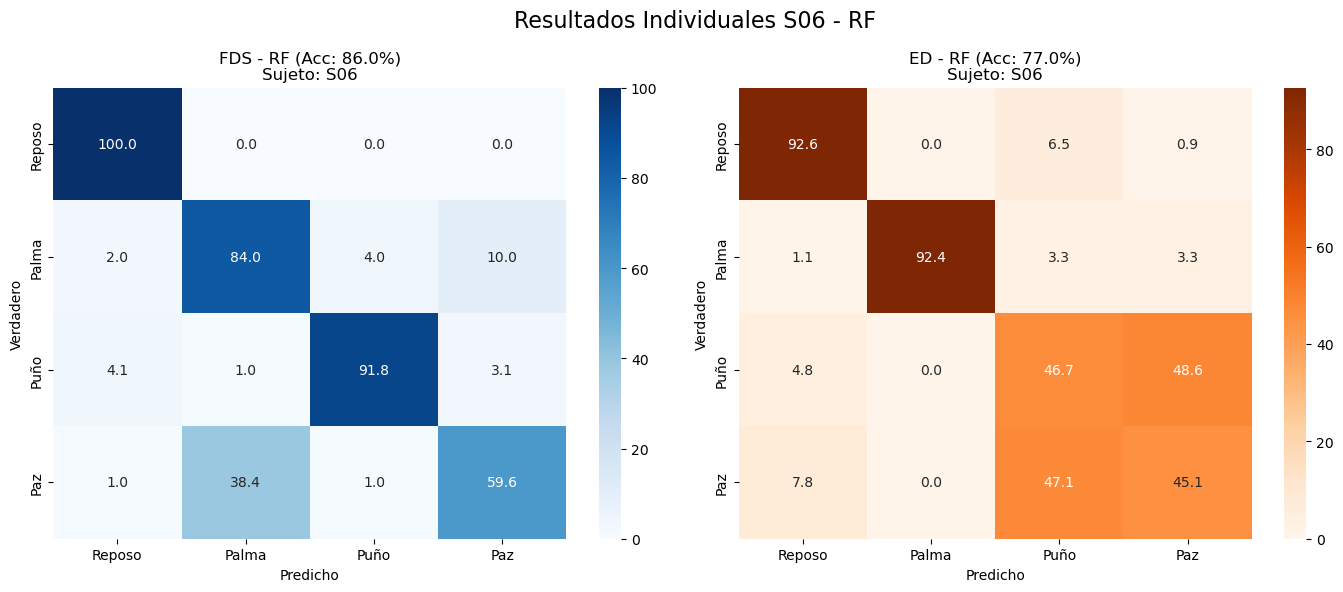


--- Reporte de Clasificación S06 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.96      1.00      0.98       160
       Palma       0.68      0.84      0.75       100
        Puño       0.95      0.92      0.93        97
         Paz       0.82      0.60      0.69        99

    accuracy                           0.86       456
   macro avg       0.85      0.84      0.84       456
weighted avg       0.87      0.86      0.86       456

--- Reporte de Clasificación S06 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.93      0.94       217
       Palma       1.00      0.92      0.96        92
        Puño       0.54      0.47      0.50       105
         Paz       0.29      0.45      0.35        51

    accuracy                           0.77       465
   macro avg       0.70      0.69      0.69       465
weighted avg       0.80      0.77      0.78       465



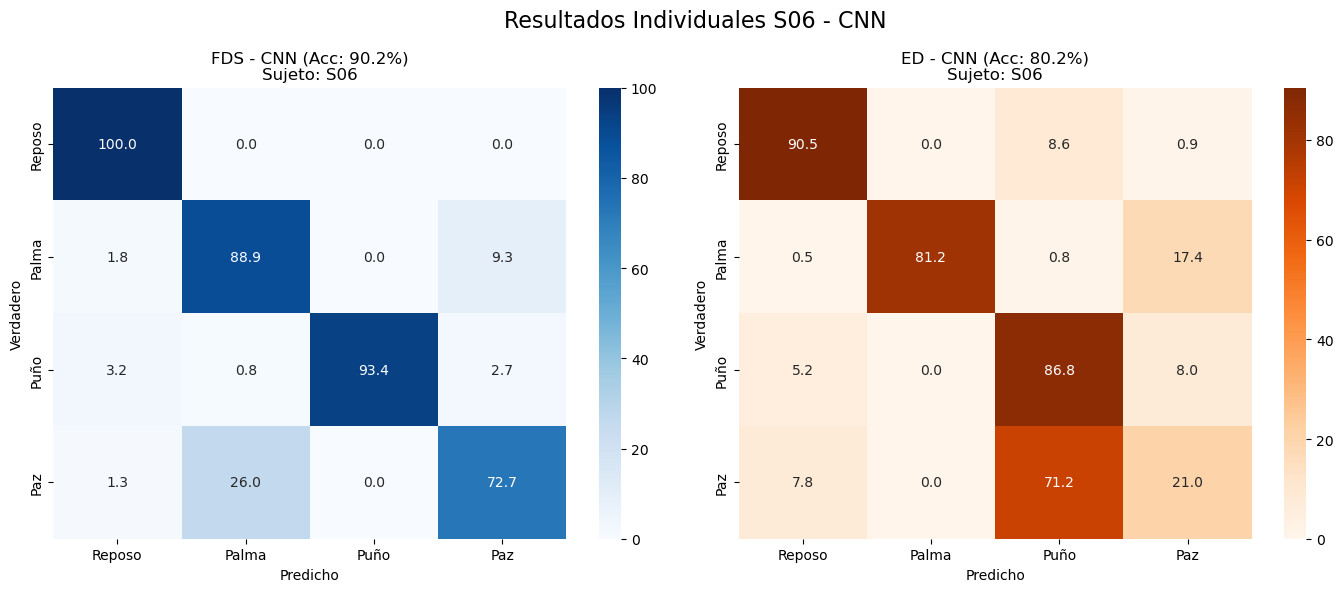


--- Reporte de Clasificación S06 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.96      1.00      0.98       611
       Palma       0.77      0.89      0.83       389
        Puño       1.00      0.93      0.97       376
         Paz       0.86      0.73      0.79       384

    accuracy                           0.90      1760
   macro avg       0.90      0.89      0.89      1760
weighted avg       0.91      0.90      0.90      1760

--- Reporte de Clasificación S06 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.90      0.93       881
       Palma       1.00      0.81      0.90       373
        Puño       0.62      0.87      0.72       424
         Paz       0.29      0.21      0.24       205

    accuracy                           0.80      1883
   macro avg       0.71      0.70      0.70      1883
weighted avg       0.81      0.80      0.80      1883


=== RESULTADOS INDIVIDUALES: S07 ==

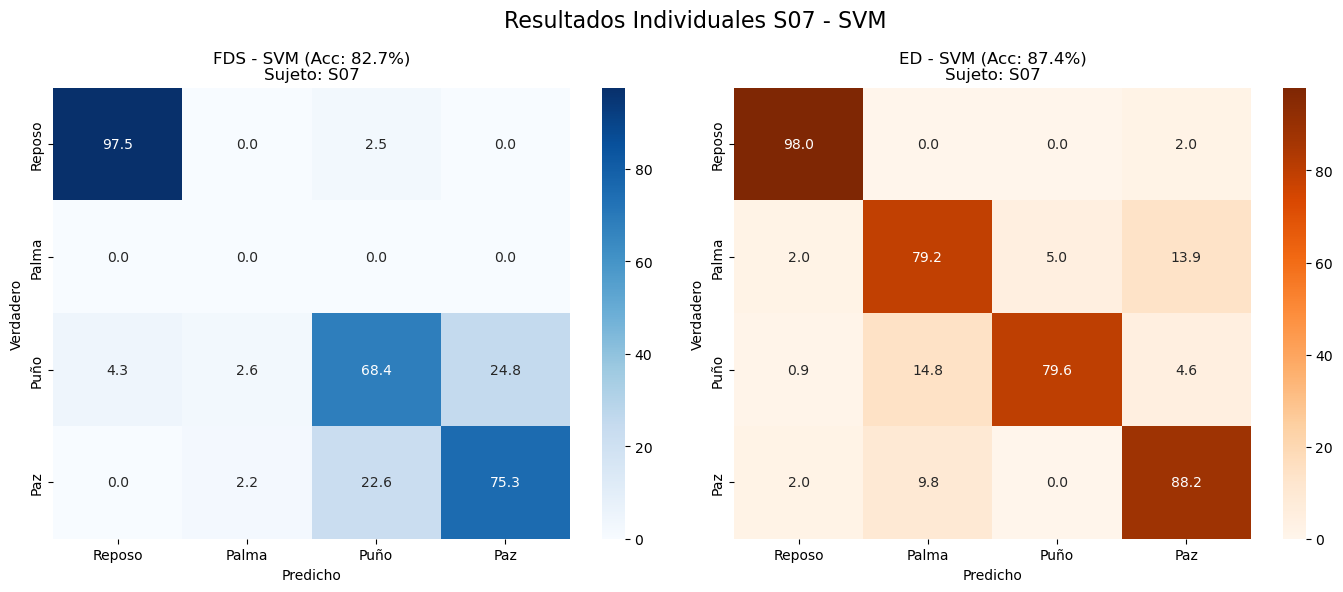


--- Reporte de Clasificación S07 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.97      0.97       159
       Palma       0.00      0.00      0.00         0
        Puño       0.76      0.68      0.72       117
         Paz       0.71      0.75      0.73        93

    accuracy                           0.83       369
   macro avg       0.61      0.60      0.61       369
weighted avg       0.84      0.83      0.83       369

--- Reporte de Clasificación S07 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.98      0.97       148
       Palma       0.75      0.79      0.77       101
        Puño       0.95      0.80      0.86       108
         Paz       0.80      0.88      0.84       102

    accuracy                           0.87       459
   macro avg       0.87      0.86      0.86       459
weighted avg       0.88      0.87      0.87       459



/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

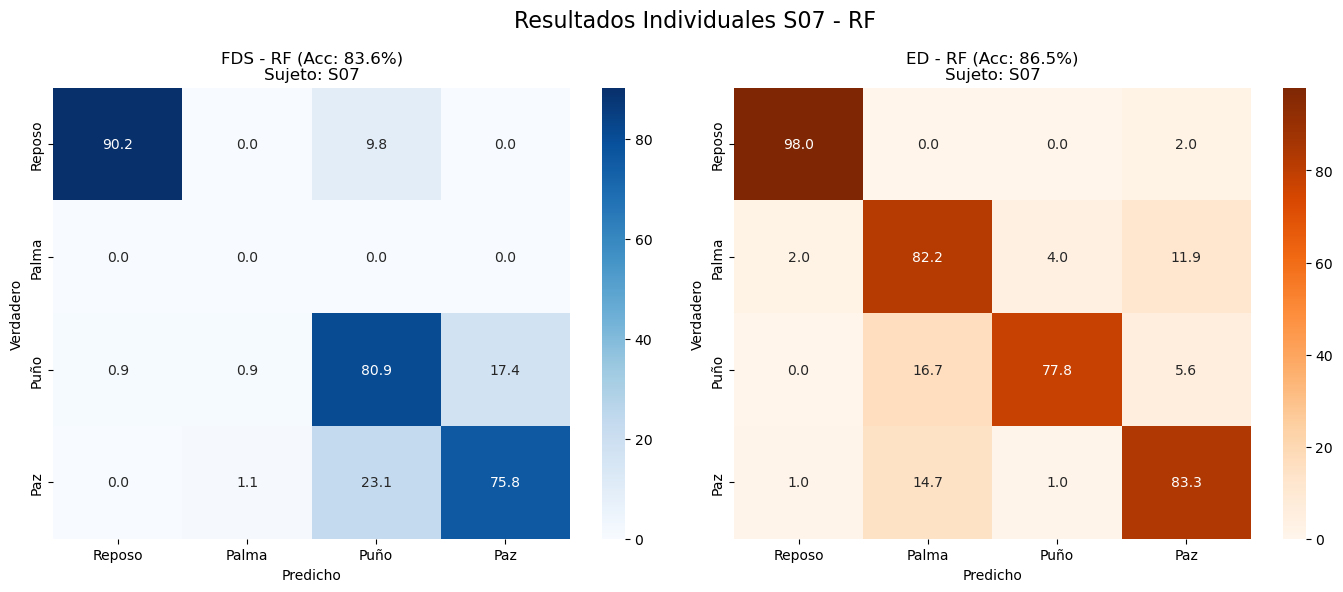


--- Reporte de Clasificación S07 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.90      0.95       153
       Palma       0.00      0.00      0.00         0
        Puño       0.72      0.81      0.76       115
         Paz       0.78      0.76      0.77        91

    accuracy                           0.84       359
   macro avg       0.62      0.62      0.62       359
weighted avg       0.85      0.84      0.84       359

--- Reporte de Clasificación S07 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.98      0.98       148
       Palma       0.72      0.82      0.76       101
        Puño       0.94      0.78      0.85       108
         Paz       0.80      0.83      0.82       102

    accuracy                           0.86       459
   macro avg       0.86      0.85      0.85       459
weighted avg       0.87      0.86      0.87       459



/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

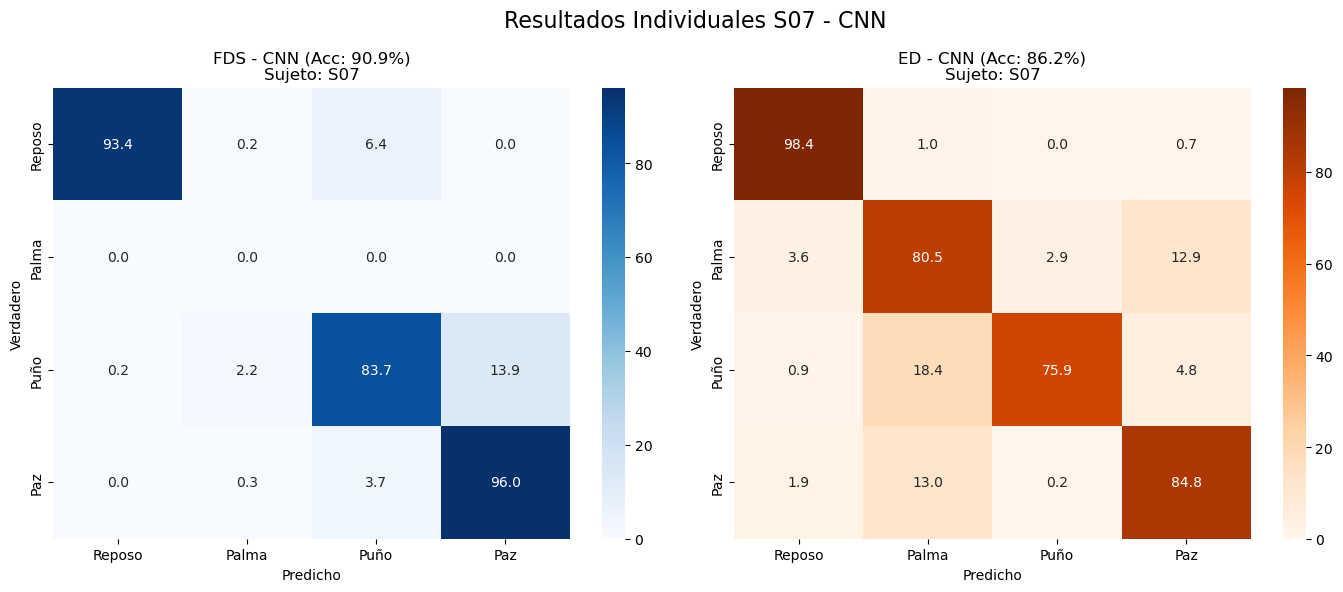


--- Reporte de Clasificación S07 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       1.00      0.93      0.97       580
       Palma       0.00      0.00      0.00         0
        Puño       0.88      0.84      0.86       447
         Paz       0.85      0.96      0.90       354

    accuracy                           0.91      1381
   macro avg       0.68      0.68      0.68      1381
weighted avg       0.92      0.91      0.91      1381

--- Reporte de Clasificación S07 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.96      0.98      0.97       607
       Palma       0.70      0.81      0.75       411
        Puño       0.96      0.76      0.85       435
         Paz       0.82      0.85      0.83       414

    accuracy                           0.86      1867
   macro avg       0.86      0.85      0.85      1867
weighted avg       0.87      0.86      0.86      1867


=== RESULTADOS INDIVIDUALES: S08 ==

/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

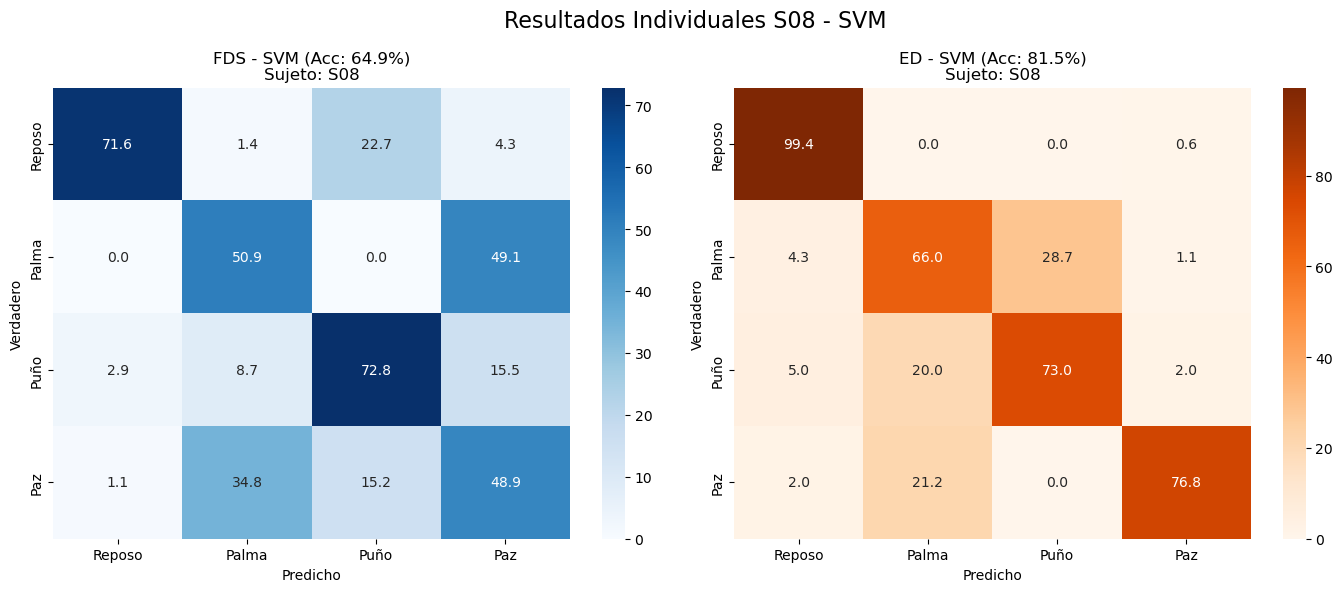


--- Reporte de Clasificación S08 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.72      0.83       211
       Palma       0.38      0.51      0.44        53
        Puño       0.55      0.73      0.62       103
         Paz       0.47      0.49      0.48        92

    accuracy                           0.65       459
   macro avg       0.59      0.61      0.59       459
weighted avg       0.71      0.65      0.67       459

--- Reporte de Clasificación S08 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.93      0.99      0.96       155
       Palma       0.60      0.66      0.63        94
        Puño       0.73      0.73      0.73       100
         Paz       0.95      0.77      0.85        99

    accuracy                           0.81       448
   macro avg       0.80      0.79      0.79       448
weighted avg       0.82      0.81      0.82       448



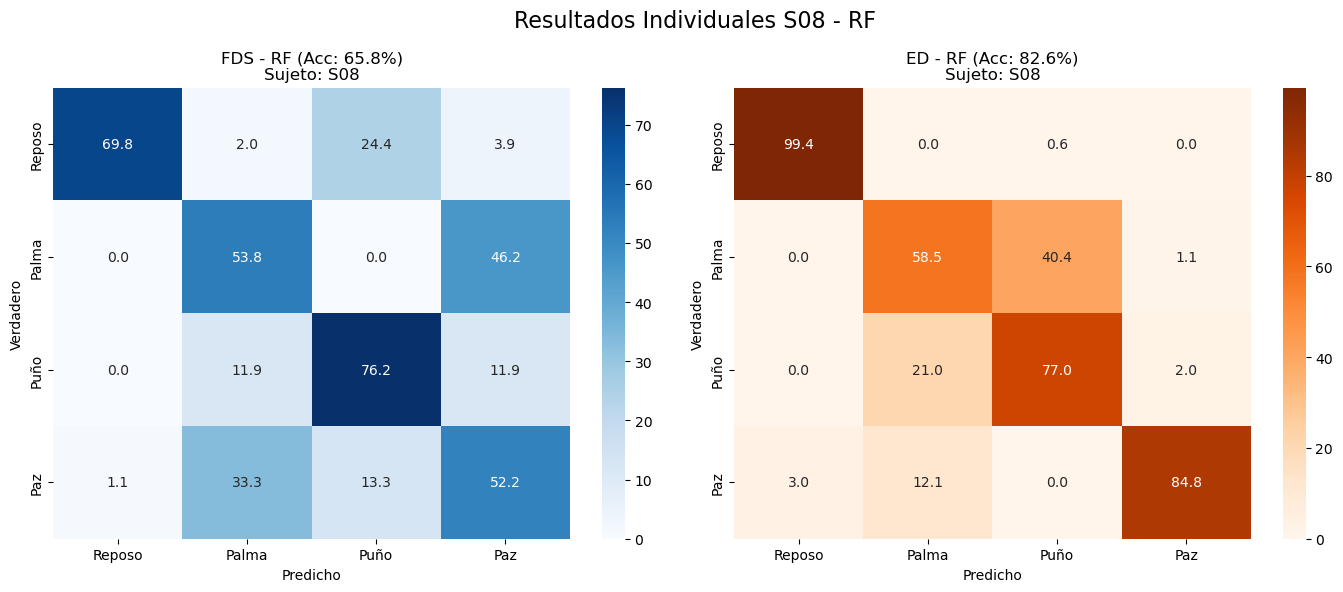


--- Reporte de Clasificación S08 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.99      0.70      0.82       205
       Palma       0.38      0.54      0.44        52
        Puño       0.55      0.76      0.64       101
         Paz       0.52      0.52      0.52        90

    accuracy                           0.66       448
   macro avg       0.61      0.63      0.61       448
weighted avg       0.73      0.66      0.68       448

--- Reporte de Clasificación S08 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.99      0.99       155
       Palma       0.62      0.59      0.60        94
        Puño       0.66      0.77      0.71       100
         Paz       0.97      0.85      0.90        99

    accuracy                           0.83       448
   macro avg       0.81      0.80      0.80       448
weighted avg       0.83      0.83      0.83       448



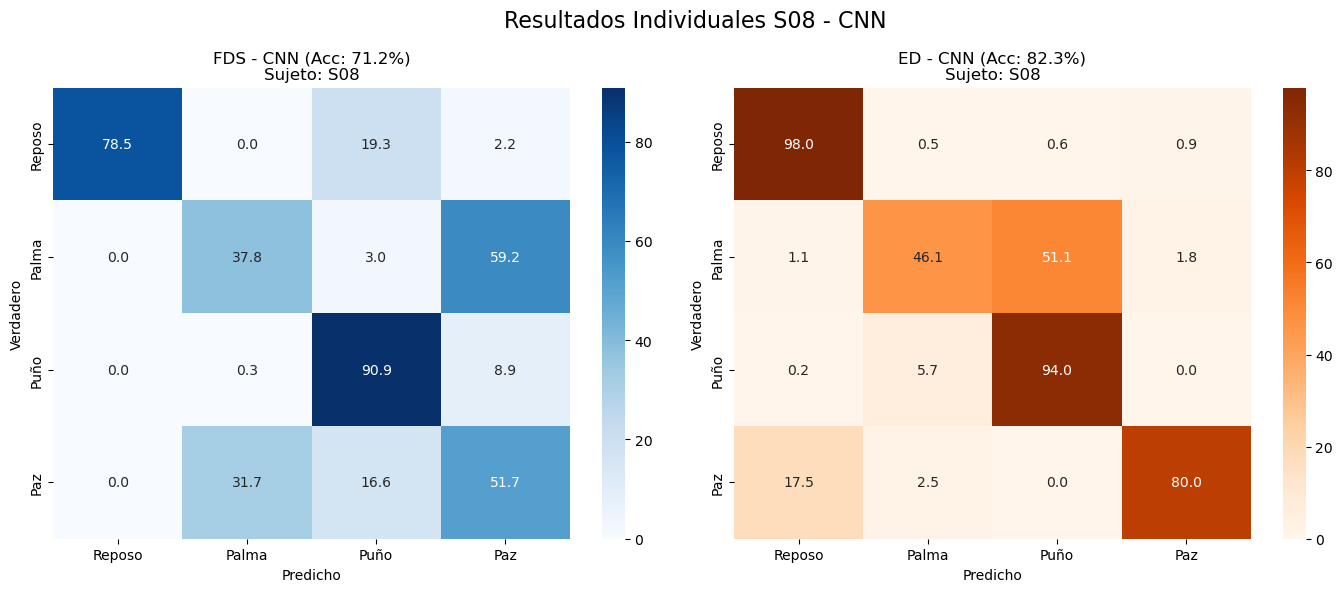


--- Reporte de Clasificación S08 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       1.00      0.78      0.88       786
       Palma       0.40      0.38      0.39       201
        Puño       0.62      0.91      0.74       395
         Paz       0.51      0.52      0.52       350

    accuracy                           0.71      1732
   macro avg       0.64      0.65      0.63      1732
weighted avg       0.75      0.71      0.72      1732

--- Reporte de Clasificación S08 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.89      0.98      0.93       637
       Palma       0.83      0.46      0.59       380
        Puño       0.66      0.94      0.77       402
         Paz       0.96      0.80      0.87       401

    accuracy                           0.82      1820
   macro avg       0.83      0.80      0.79      1820
weighted avg       0.84      0.82      0.81      1820


=== RESULTADOS INDIVIDUALES: S10 ==

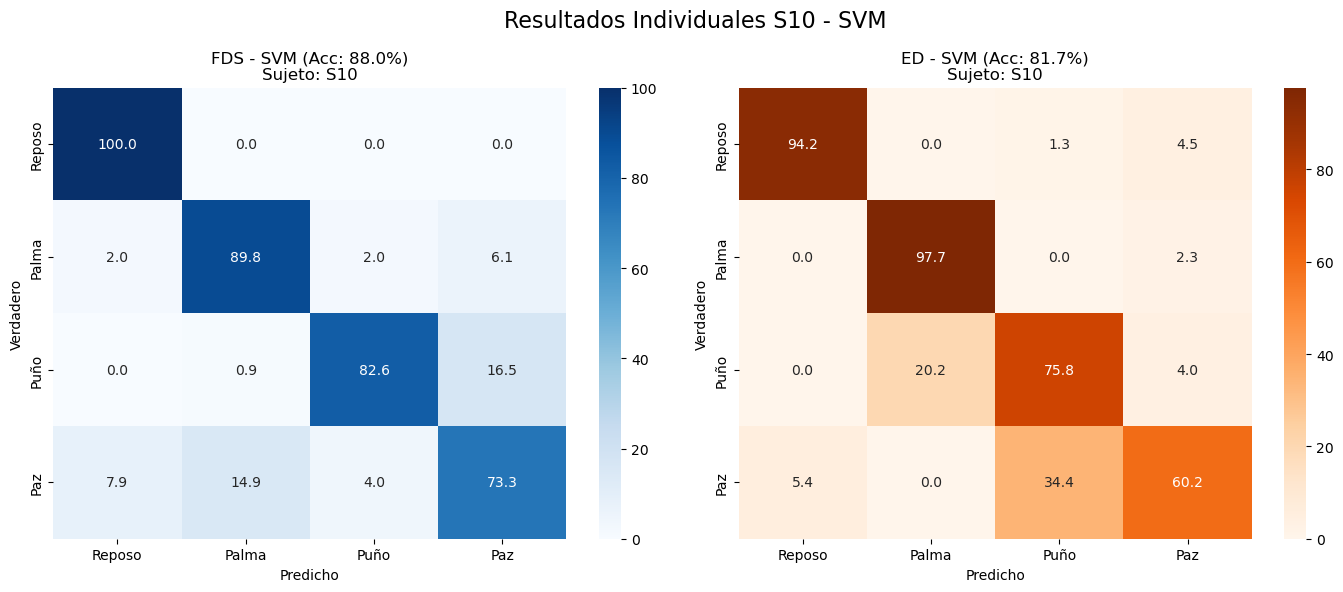


--- Reporte de Clasificación S10 FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.94      1.00      0.97       160
       Palma       0.85      0.90      0.87        98
        Puño       0.94      0.83      0.88       109
         Paz       0.76      0.73      0.74       101

    accuracy                           0.88       468
   macro avg       0.87      0.86      0.87       468
weighted avg       0.88      0.88      0.88       468

--- Reporte de Clasificación S10 ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.94      0.95       154
       Palma       0.68      0.98      0.80        43
        Puño       0.69      0.76      0.72        99
         Paz       0.82      0.60      0.70        93

    accuracy                           0.82       389
   macro avg       0.79      0.82      0.79       389
weighted avg       0.83      0.82      0.82       389



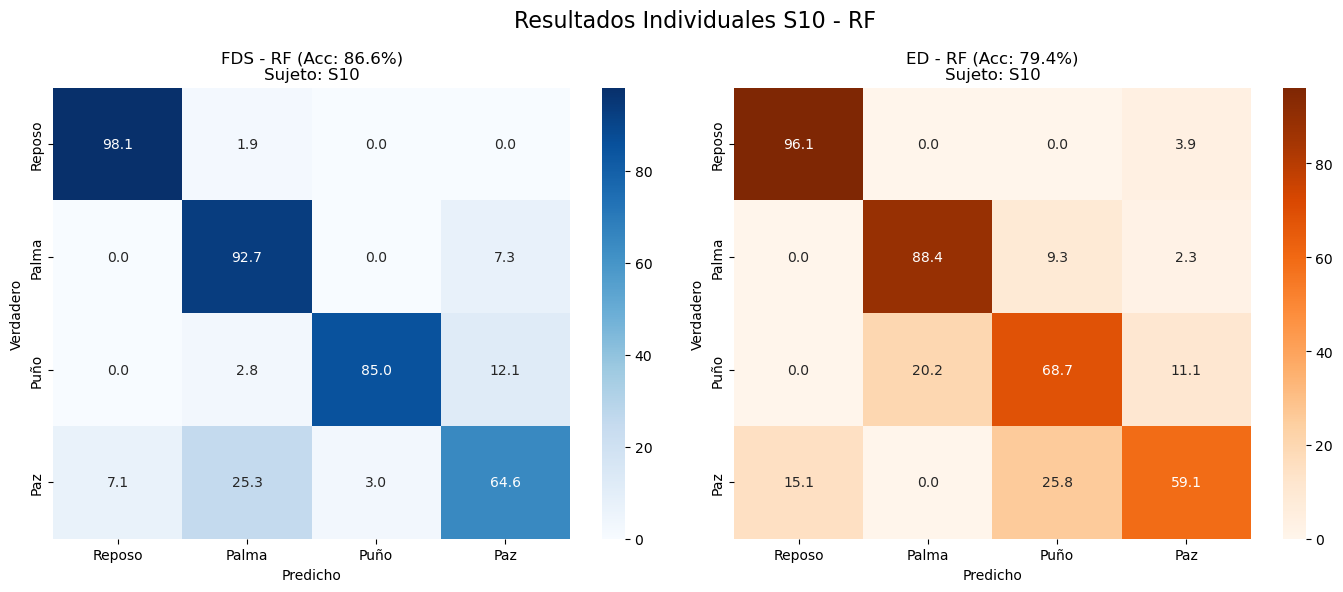


--- Reporte de Clasificación S10 FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.96      0.98      0.97       154
       Palma       0.74      0.93      0.82        96
        Puño       0.97      0.85      0.91       107
         Paz       0.76      0.65      0.70        99

    accuracy                           0.87       456
   macro avg       0.86      0.85      0.85       456
weighted avg       0.87      0.87      0.86       456

--- Reporte de Clasificación S10 ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.91      0.96      0.94       154
       Palma       0.66      0.88      0.75        43
        Puño       0.71      0.69      0.70        99
         Paz       0.75      0.59      0.66        93

    accuracy                           0.79       389
   macro avg       0.76      0.78      0.76       389
weighted avg       0.79      0.79      0.79       389



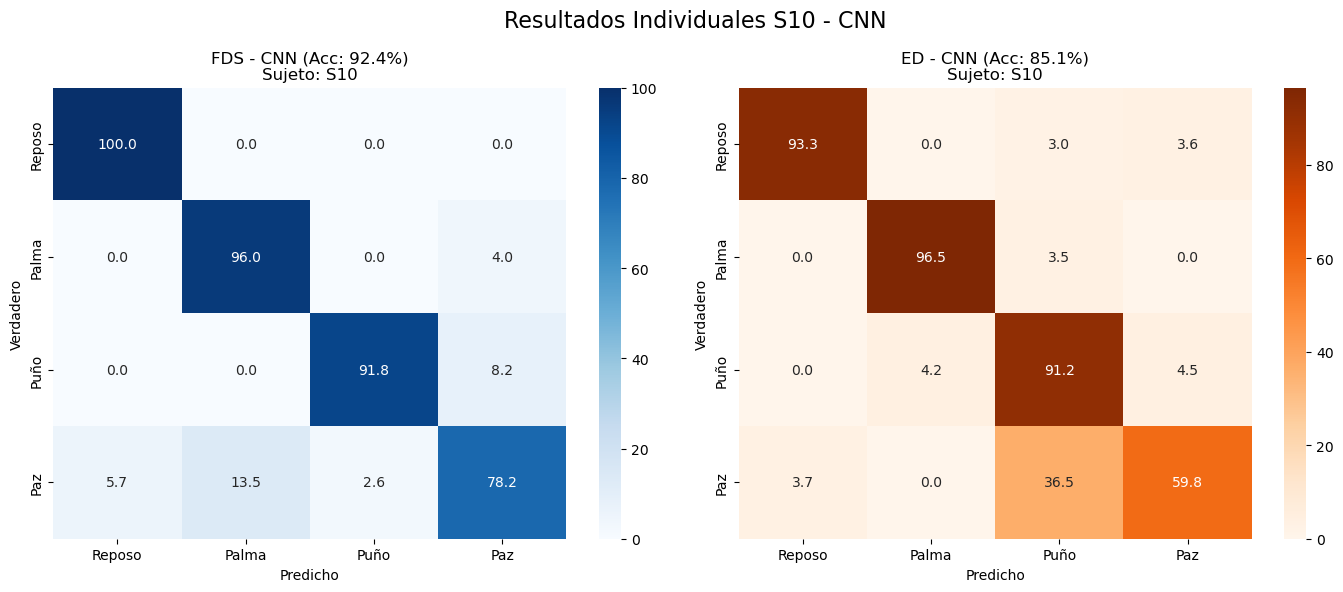


--- Reporte de Clasificación S10 FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.96      1.00      0.98       582
       Palma       0.87      0.96      0.91       375
        Puño       0.97      0.92      0.95       417
         Paz       0.86      0.78      0.82       385

    accuracy                           0.92      1759
   macro avg       0.92      0.92      0.92      1759
weighted avg       0.92      0.92      0.92      1759

--- Reporte de Clasificación S10 ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.98      0.93      0.95       631
       Palma       0.91      0.97      0.94       173
        Puño       0.69      0.91      0.79       400
         Paz       0.85      0.60      0.70       378

    accuracy                           0.85      1582
   macro avg       0.86      0.85      0.84      1582
weighted avg       0.87      0.85      0.85      1582



In [3]:
def plot_individual_results(subject, model_name, res_fds, res_ed):
    if not res_fds or not res_ed:
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # FDS
    cm_fds = confusion_matrix(res_fds['y_true'], res_fds['y_pred'], labels=list(range(NUM_CLASSES)))
    cm_fds_norm = cm_fds.astype('float') / (cm_fds.sum(axis=1)[:, np.newaxis] + 1e-9)
    sns.heatmap(cm_fds_norm * 100, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title(f'FDS - {model_name} (Acc: {res_fds["acc"]*100:.1f}%)\nSujeto: {subject}')
    axes[0].set_ylabel('Verdadero')
    axes[0].set_xlabel('Predicho')
    
    # ED
    cm_ed = confusion_matrix(res_ed['y_true'], res_ed['y_pred'], labels=list(range(NUM_CLASSES)))
    cm_ed_norm = cm_ed.astype('float') / (cm_ed.sum(axis=1)[:, np.newaxis] + 1e-9)
    sns.heatmap(cm_ed_norm * 100, annot=True, fmt='.1f', cmap='Oranges', 
                xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title(f'ED - {model_name} (Acc: {res_ed["acc"]*100:.1f}%)\nSujeto: {subject}')
    axes[1].set_ylabel('Verdadero')
    axes[1].set_xlabel('Predicho')
    
    plt.suptitle(f'Resultados Individuales {subject} - {model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- Reporte de Clasificación {subject} FDS ({model_name}) ---")
    print(classification_report(res_fds['y_true'], res_fds['y_pred'], target_names=classes))
    print(f"--- Reporte de Clasificación {subject} ED ({model_name}) ---")
    print(classification_report(res_ed['y_true'], res_ed['y_pred'], target_names=classes))

for subject in subjects:
    print(f"\n{'='*80}")
    print(f"=== RESULTADOS INDIVIDUALES: {subject} ===")
    print(f"{'='*80}")
    for model_name in ['SVM', 'RF', 'CNN']:
        res_fds = results[subject]['FDS'].get(model_name, {})
        res_ed = results[subject]['ED'].get(model_name, {})
        plot_individual_results(subject, model_name, res_fds, res_ed)


## Resultados Agregados (Todos los Sujetos)

A continuación, visualizaremos las matrices de confusión acumuladas y el reporte general, para comparar globalmente las asimetrías.


=== RESULTADOS AGREGADOS (TODOS LOS SUJETOS) ===


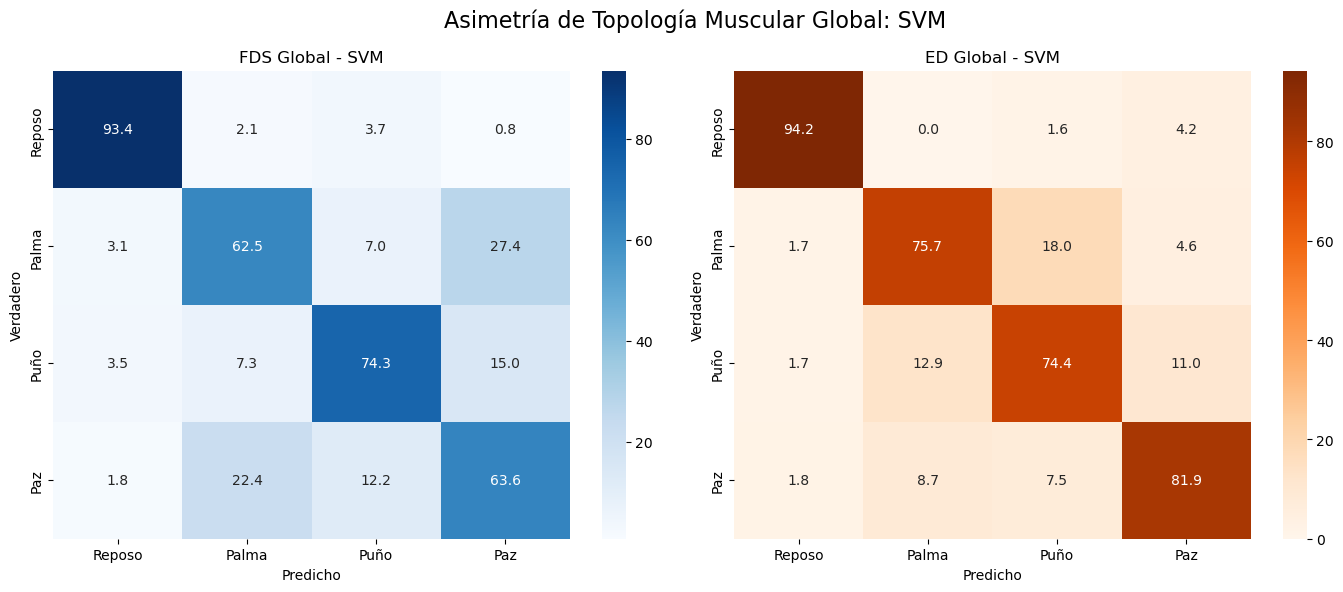


--- Reporte de Clasificación Global FDS (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.95      0.93      0.94      1509
       Palma       0.61      0.63      0.62       731
        Puño       0.73      0.74      0.74       809
         Paz       0.63      0.64      0.63       902

    accuracy                           0.77      3951
   macro avg       0.73      0.73      0.73      3951
weighted avg       0.77      0.77      0.77      3951

--- Reporte de Clasificación Global ED (SVM) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.94      0.95      1449
       Palma       0.77      0.76      0.76       828
        Puño       0.75      0.74      0.75       929
         Paz       0.77      0.82      0.79       814

    accuracy                           0.83      4020
   macro avg       0.81      0.82      0.81      4020
weighted avg       0.84      0.83      0.83      4020



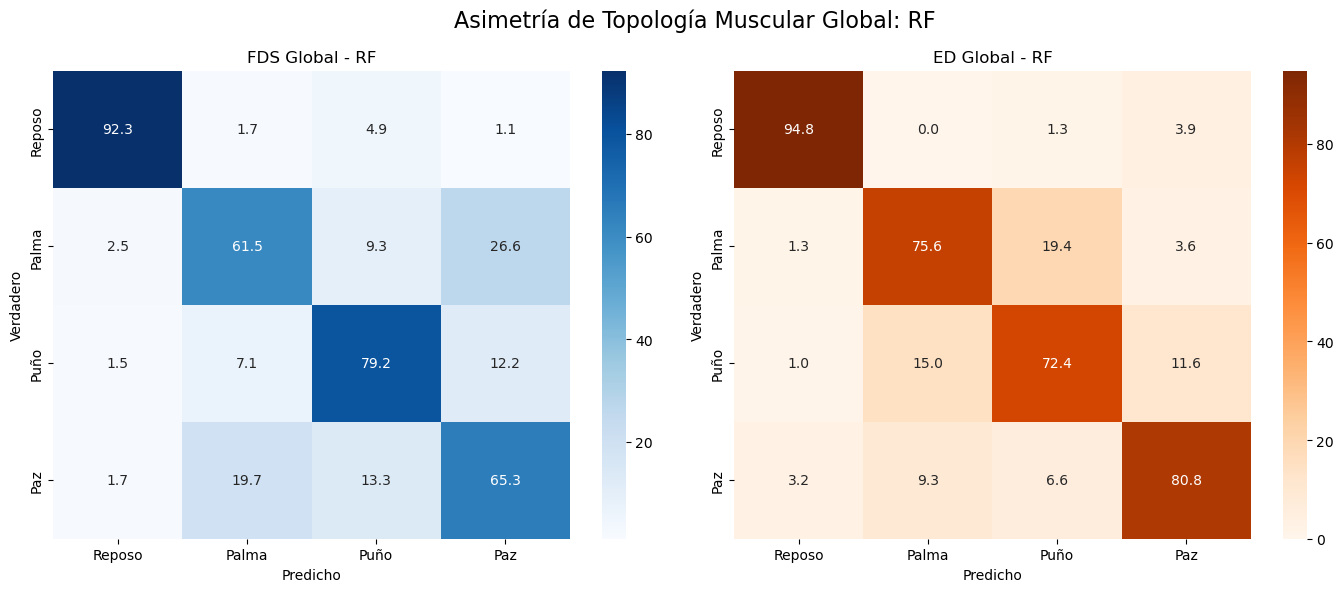


--- Reporte de Clasificación Global FDS (RF) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.92      0.94      1454
       Palma       0.63      0.62      0.62       717
        Puño       0.71      0.79      0.75       794
         Paz       0.65      0.65      0.65       884

    accuracy                           0.78      3849
   macro avg       0.74      0.75      0.74      3849
weighted avg       0.78      0.78      0.78      3849

--- Reporte de Clasificación Global ED (RF) ---
              precision    recall  f1-score   support

      Reposo       0.97      0.95      0.96      1449
       Palma       0.74      0.76      0.75       828
        Puño       0.74      0.72      0.73       929
         Paz       0.77      0.81      0.79       814

    accuracy                           0.83      4020
   macro avg       0.81      0.81      0.81      4020
weighted avg       0.83      0.83      0.83      4020



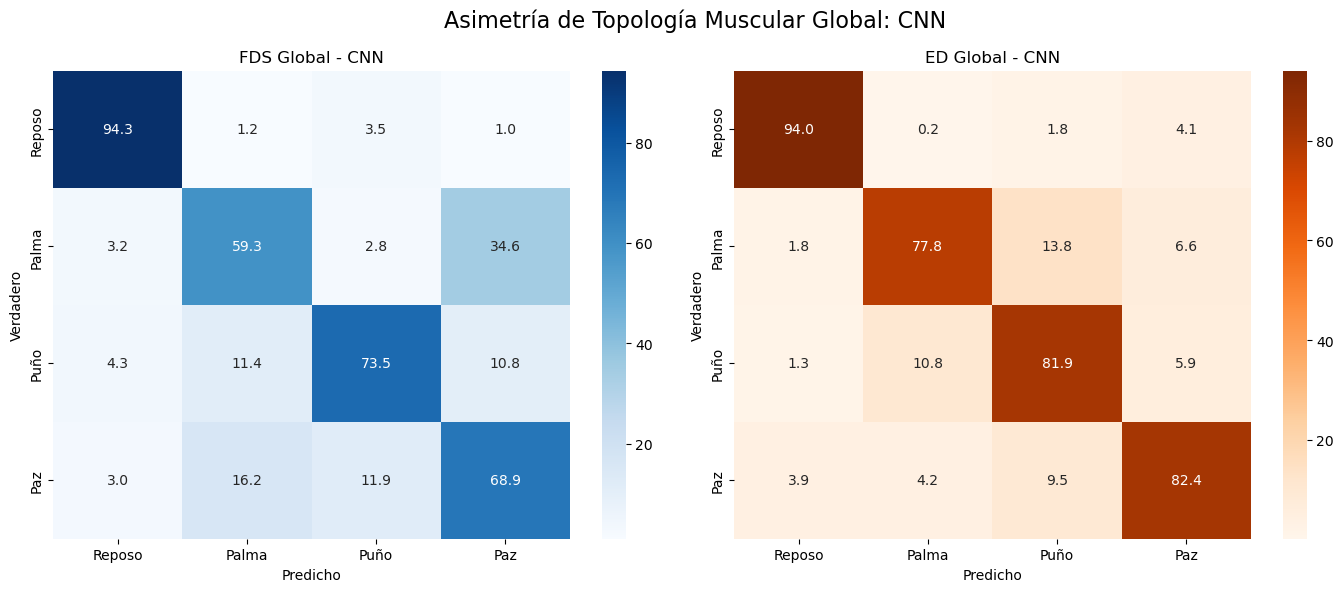


--- Reporte de Clasificación Global FDS (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.94      0.94      0.94      5521
       Palma       0.63      0.59      0.61      2790
        Puño       0.77      0.74      0.75      3085
         Paz       0.64      0.69      0.66      3439

    accuracy                           0.78     14835
   macro avg       0.74      0.74      0.74     14835
weighted avg       0.78      0.78      0.78     14835

--- Reporte de Clasificación Global ED (CNN) ---
              precision    recall  f1-score   support

      Reposo       0.96      0.94      0.95      5921
       Palma       0.83      0.78      0.80      3354
        Puño       0.78      0.82      0.80      3755
         Paz       0.80      0.82      0.81      3301

    accuracy                           0.86     16331
   macro avg       0.84      0.84      0.84     16331
weighted avg       0.86      0.86      0.86     16331



In [4]:
def plot_aggregate_results(model_name, results_dict, subjects):
    y_true_fds_all, y_pred_fds_all = [], []
    y_true_ed_all, y_pred_ed_all = [], []
    
    for sub in subjects:
        if model_name in results_dict[sub]['FDS']:
            y_true_fds_all.extend(results_dict[sub]['FDS'][model_name]['y_true'])
            y_pred_fds_all.extend(results_dict[sub]['FDS'][model_name]['y_pred'])
        if model_name in results_dict[sub]['ED']:
            y_true_ed_all.extend(results_dict[sub]['ED'][model_name]['y_true'])
            y_pred_ed_all.extend(results_dict[sub]['ED'][model_name]['y_pred'])
            
    if not y_true_fds_all or not y_true_ed_all:
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # FDS Agregado
    cm_fds = confusion_matrix(y_true_fds_all, y_pred_fds_all, labels=list(range(NUM_CLASSES)))
    cm_fds_norm = cm_fds.astype('float') / (cm_fds.sum(axis=1)[:, np.newaxis] + 1e-9)
    sns.heatmap(cm_fds_norm * 100, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title(f'FDS Global - {model_name}')
    axes[0].set_ylabel('Verdadero')
    axes[0].set_xlabel('Predicho')
    
    # ED Agregado
    cm_ed = confusion_matrix(y_true_ed_all, y_pred_ed_all, labels=list(range(NUM_CLASSES)))
    cm_ed_norm = cm_ed.astype('float') / (cm_ed.sum(axis=1)[:, np.newaxis] + 1e-9)
    sns.heatmap(cm_ed_norm * 100, annot=True, fmt='.1f', cmap='Oranges', 
                xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title(f'ED Global - {model_name}')
    axes[1].set_ylabel('Verdadero')
    axes[1].set_xlabel('Predicho')
    
    plt.suptitle(f'Asimetría de Topología Muscular Global: {model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- Reporte de Clasificación Global FDS ({model_name}) ---")
    print(classification_report(y_true_fds_all, y_pred_fds_all, target_names=classes))
    print(f"--- Reporte de Clasificación Global ED ({model_name}) ---")
    print(classification_report(y_true_ed_all, y_pred_ed_all, target_names=classes))

print(f"\n{'='*80}")
print(f"=== RESULTADOS AGREGADOS (TODOS LOS SUJETOS) ===")
print(f"{'='*80}")
for model_name in ['SVM', 'RF', 'CNN']:
    plot_aggregate_results(model_name, results, subjects)


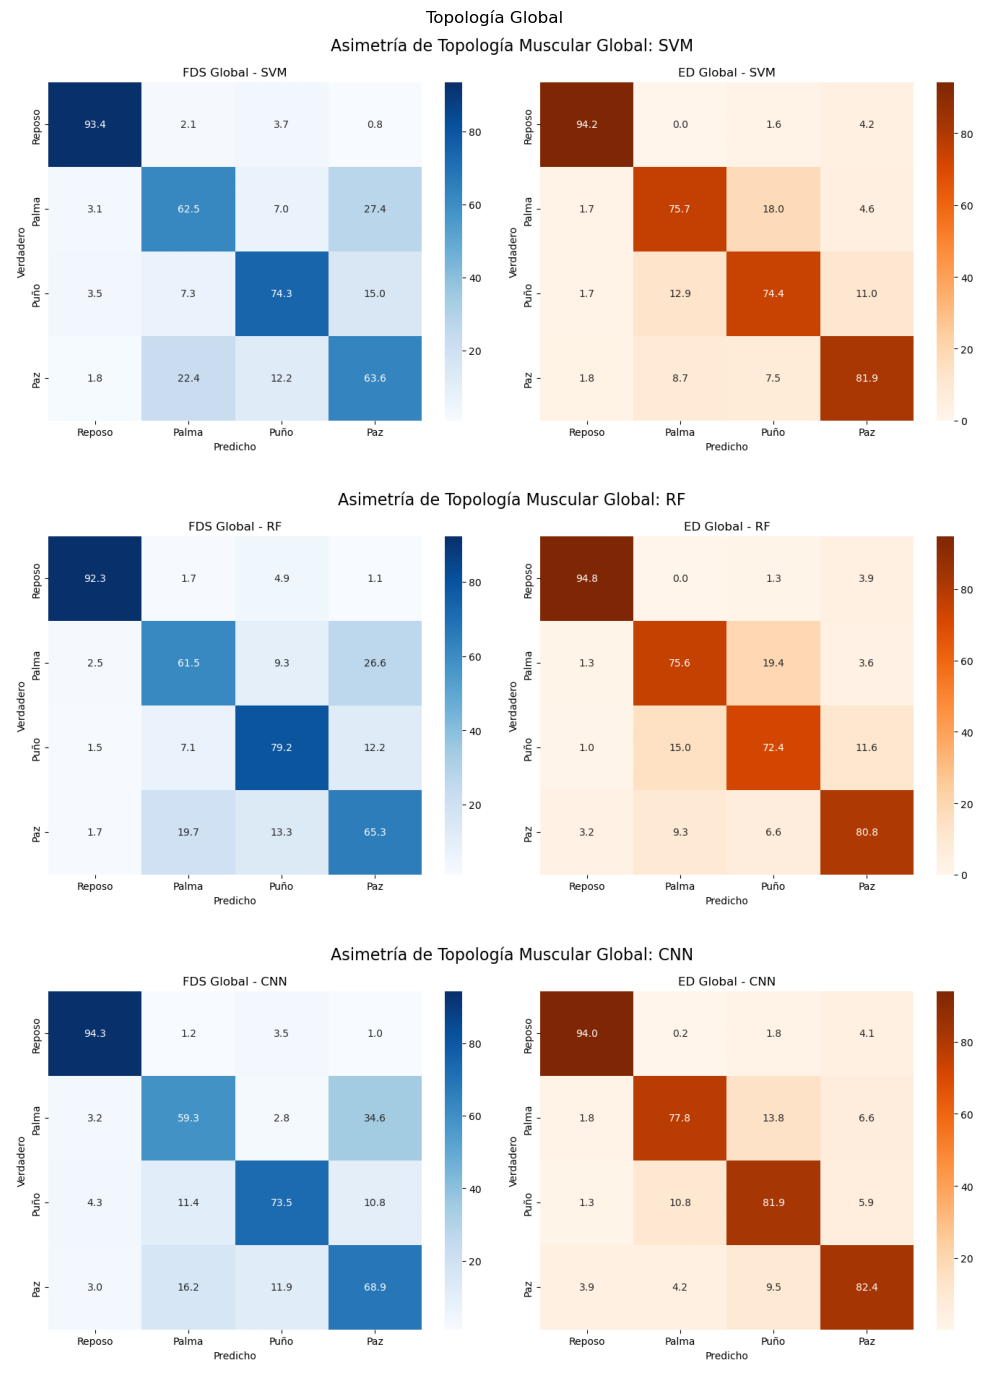

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(3, 1, figsize=(10, 14))
models = ['svm', 'rf', 'nn']
titles = ['SVM', 'RF', 'CNN-LSTM']
axes[0].set_title(f"Topología Global")
for i, model in enumerate(models):
    ax = axes[i]
    img_path = f"/home/cbe/Proyectos/MyoTensor_Tesis/docs/images/global{model}.png"
    try:
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        
    except FileNotFoundError:
        ax.set_title(f"Imagen no encontrada:\nglobal{model}.png")
        ax.axis('off')

plt.tight_layout()
plt.show()